 # Bitcoin Price Prediction


La variable objetivo es el **retorno logarítmico del precio Close**. Esta transformación garantiza estacionariedad en la serie, como se demostró en el EDA mediante el test ADF.

## Setup y carga de datos

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import time
import warnings
import joblib
import os
warnings.filterwarnings('ignore')

# Pipeline y preprocesamiento
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Modelos
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import LinearSVR
from xgboost import XGBRegressor

# ARIMA
from statsmodels.tsa.arima.model import ARIMA

# Optimización
from itertools import product
from scipy.stats import randint, uniform
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from deap import base, creator, tools, algorithms
import random

# Split temporal
from tsxv.splitTrainValTest import split_train_val_test_groupKFold

# Tests estadísticos
from statsmodels.tsa.stattools import bds
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf
from scipy import stats

# LIME
import lime
import lime.lime_tabular
from IPython.display import display


# Directorio de salida para artefactos
os.makedirs('outputs', exist_ok=True)

print('Librerías cargadas correctamente')


Librerías cargadas correctamente


In [39]:
# Carga y preprocesamiento de datos 
datos = pd.read_csv('data.csv')
datos['TimestampConventional'] = pd.to_datetime(datos['Timestamp'], unit='s')
datos.set_index('TimestampConventional', inplace=True)

df = datos['2019':][["Open","High","Low","Close","Volume"]].resample('15min').mean()
df = df.dropna()

print(f'Datos cargados: {df.shape[0]:,} observaciones')
print(f'Periodo: {df.index[0]} → {df.index[-1]}')

Datos cargados: 250,581 observaciones
Periodo: 2019-01-01 00:00:00 → 2026-02-24 00:00:00


El dataset queda con 250.581 observaciones y en el periodo del 2019-01-01 hasta el 2026-02-24

## Construcción de features

La variable objetivo es el **retorno logarítmico del Close**. Como el EDA mostró que 7 lags captura la memoria relevante de la serie (menor RMSE y residuos independientes según BDS), se usan **7 lags** como features de entrada.

Serie de retornos: 250,580 observaciones
Media: 0.000011 | Std: 0.002869


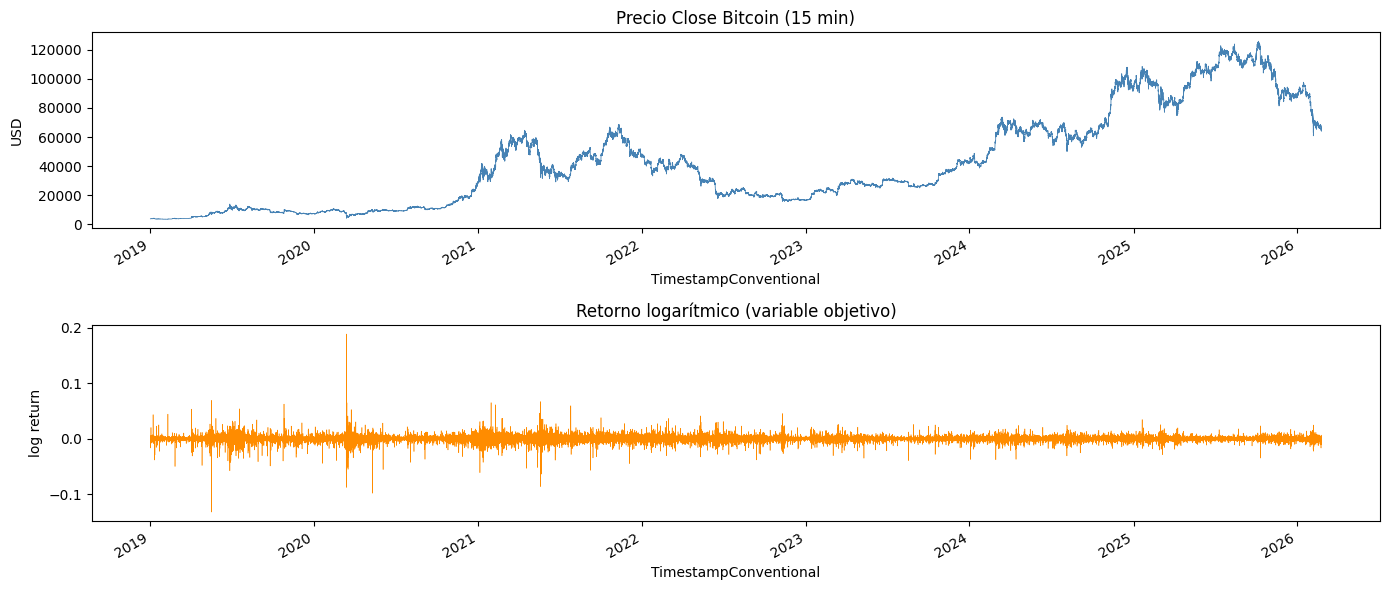

In [40]:
# Retorno logarítmico
log_return = np.log(df['Close']).diff().dropna()

# Parámetros del problema
N_LAGS     = 7   # inputs: 7 pasos previos
N_STEPS    = 1   # output: predecir 1 paso adelante
N_JUMP     = 1   # salto en cada muestra
RANDOM_SEED = 42

print(f'Serie de retornos: {len(log_return):,} observaciones')
print(f'Media: {log_return.mean():.6f} | Std: {log_return.std():.6f}')

# Visualización rápida
fig, axes = plt.subplots(2, 1, figsize=(14, 6))
df['Close'].plot(ax=axes[0], color='steelblue', linewidth=0.6)
axes[0].set_title('Precio Close Bitcoin (15 min)')
axes[0].set_ylabel('USD')

log_return.plot(ax=axes[1], color='darkorange', linewidth=0.4)
axes[1].set_title('Retorno logarítmico (variable objetivo)')
axes[1].set_ylabel('log return')

plt.tight_layout()
plt.show()

La media de 0.000011 la cual es practicamente cero confirman que el Bitcoin no sube ni baja de forma consistente cada 15 minutos. Se puede observar en la grafica de abajo oscila consistentemente alredodr de 0 a lo largo de todo el periodo de tiempo excepto en 2020 lo cual corresponde al crash de marzo de 2020 por COVID. En la grafica de arriba se confirma lo visto en el EDA como los 2 ciclos alcistas y la tendencia alcista a largo plazo.

## Validacion temporal 

Al tratarse de una serie de tiempo, no se puede usar un split aleatorio el futuro no puede entrenar y el pasado evaluar. La librería `tsxv` implementa 
`split_train_val_test_groupKFold`, que divide los datos en bloques temporales 
consecutivos garantizando este orden en todos los folds.

In [41]:
timeSeries = log_return.values.reshape(-1, 1)

X, y, Xcv, ycv, Xtest, ytest = split_train_val_test_groupKFold(
    timeSeries,
    numInputs=N_LAGS,
    numOutputs=N_STEPS,
    numJumps=N_JUMP
)

print(f'Número de folds: {len(X)}')
for fold in range(len(X)):
    print(f'Fold {fold} — Train: {X[fold].shape[0]:,} | '
          f'Val: {Xcv[fold].shape[0]:,} | '
          f'Test: {Xtest[fold].shape[0]:,}')

Número de folds: 5
Fold 0 — Train: 32,686 | Val: 10,895 | Test: 10,894
Fold 1 — Train: 32,685 | Val: 10,895 | Test: 10,894
Fold 2 — Train: 32,684 | Val: 10,895 | Test: 10,894
Fold 3 — Train: 32,683 | Val: 10,895 | Test: 10,894
Fold 4 — Train: 32,682 | Val: 10,895 | Test: 10,895


La validación temporal implementada en este proyecto permite evaluar el modelo respetando el orden cronológico de los datos del Bitcoin. Esto es importante porque en las series de tiempo no se puede mezclar información futura con datos del pasado, ya que esto generaría resultados irreales y un sobreajuste del modelo.

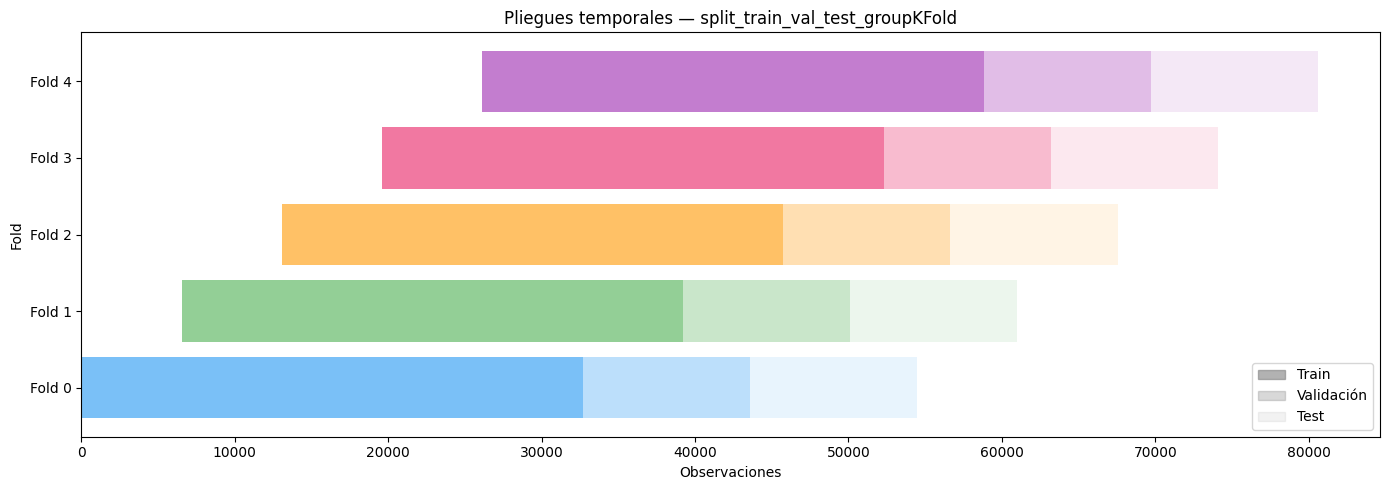

In [42]:
# Visualización de los pliegues
fig, ax = plt.subplots(figsize=(14, 5))

n_total = len(log_return)
colores = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']

for fold in range(len(X)):
    n_train = X[fold].shape[0]
    n_val   = Xcv[fold].shape[0]
    n_test  = Xtest[fold].shape[0]
    
    # Posición aproximada en la serie completa
    start_train = fold * (n_train // len(X))
    end_train   = start_train + n_train
    end_val     = end_train + n_val
    end_test    = end_val + n_test

    y_pos = fold

    ax.barh(y_pos, n_train, left=start_train,
            color=colores[fold], alpha=0.6, label=f'Fold {fold} Train')
    ax.barh(y_pos, n_val, left=end_train,
            color=colores[fold], alpha=0.3)
    ax.barh(y_pos, n_test, left=end_val,
            color=colores[fold], alpha=0.1)

train_patch = mpatches.Patch(color='gray', alpha=0.6, label='Train')
val_patch   = mpatches.Patch(color='gray', alpha=0.3, label='Validación')
test_patch  = mpatches.Patch(color='gray', alpha=0.1, label='Test')

ax.legend(handles=[train_patch, val_patch, test_patch], loc='lower right')
ax.set_xlabel('Observaciones')
ax.set_ylabel('Fold')
ax.set_title('Pliegues temporales — split_train_val_test_groupKFold')
ax.set_yticks(range(len(X)))
ax.set_yticklabels([f'Fold {i}' for i in range(len(X))])
plt.tight_layout()
plt.show()

En la Figura se observa la división de los datos mediante una estrategia de folds temporales consecutivos. En cada fold se utilizan tres subconjuntos correspondientes a entrenamiento, validación y prueba. El conjunto de entrenamiento contiene aproximadamente 32 mil observaciones mientras que los conjuntos de validación y prueba tienen cerca de 10 mil registros cada uno.

A medida que avanzan los folds, la ventana temporal se desplaza hacia adelante, permitiendo que el modelo aprenda con datos pasados y sea evaluado con información más reciente. Esto simula de manera más realista el comportamiento que tendría el modelo en un escenario real de predicción financiera.

Además, esta metodología ayuda a reducir el riesgo de fuga de información entre conjuntos de datos, garantizando que el modelo únicamente tenga acceso a observaciones anteriores al momento de realizar la predicción. De esta manera, los resultados obtenidos reflejan mejor la capacidad predictiva real del modelo sobre el comportamiento de los retornos del Bitcoin.

## Optimizacion de hiperparametros

Se definen los espacios de búsqueda y los modelos para los 4 métodos de 
optimización. El preprocesamiento (StandardScaler) se aplica dentro de 
cada fold, ajustándose solo con datos de entrenamiento para evitar 
data leakage temporal.

In [43]:
# Métrica de dirección — qué tan bien predice si sube o baja
def direction_accuracy(y_real, y_pred):
    y_real = y_real.ravel()
    y_pred = y_pred.ravel()

    return np.mean(
        np.sign(y_real) == np.sign(y_pred)
    )


# ─────────────────────────────────────────────────────────────────────────────
# Función de evaluación unificada: ML con StandardScaler + ARIMA sin scaler
# El condicional se activa cuando ModelClass == 'ARIMA'
# ─────────────────────────────────────────────────────────────────────────────
def evaluar_params(ModelClass, params, seed=None):
    rmses, maes, das = [], [], []

    for fold in range(len(X)):
        X_train_raw = X[fold].reshape(X[fold].shape[0], -1)
        X_test_raw  = Xtest[fold].reshape(Xtest[fold].shape[0], -1)
        y_train_raw = y[fold].reshape(y[fold].shape[0], -1)
        y_test_raw  = ytest[fold].reshape(ytest[fold].shape[0], -1).ravel()

        # ── ARIMA: sin scaler, entrena sobre la serie de entrenamiento ────────
        if ModelClass == 'ARIMA':
            try:
                fit = ARIMA(
                    y_train_raw.ravel(),
                    order=(params['p'], params['d'], params['q'])
                ).fit()
                yhat = fit.forecast(steps=len(y_test_raw))
            except Exception:
                yhat = np.zeros(len(y_test_raw))

        # ── Modelos ML: escalado fold-by-fold sin leakage ─────────────────────
        else:
            scaler_x = StandardScaler().fit(X_train_raw)
            scaler_y = StandardScaler().fit(y_train_raw)

            X_train = scaler_x.transform(X_train_raw)
            X_test_ = scaler_x.transform(X_test_raw)
            y_train = scaler_y.transform(y_train_raw).ravel()

            try:
                if seed is not None and 'random_state' in ModelClass().get_params():
                    model = ModelClass(**params, random_state=seed)
                else:
                    model = ModelClass(**params)
            except Exception:
                model = ModelClass(**params)

            model.fit(X_train, y_train)
            yhat = scaler_y.inverse_transform(
                model.predict(X_test_).reshape(-1, 1)
            ).ravel()

        rmses.append(np.sqrt(mean_squared_error(y_test_raw, yhat)))
        maes.append(mean_absolute_error(y_test_raw, yhat))
        das.append(direction_accuracy(y_test_raw, yhat))

    return np.mean(rmses), np.mean(maes), np.mean(das)


# Sentinel 'ARIMA' como clave — los param_grids/random/optuna/deap
# lo detectan por nombre; evaluar_params activa la rama correcta
modelos = {
    'KNN'          : KNeighborsRegressor,
    'Ridge'        : Ridge,
    'Lasso'        : Lasso,
    'Decision Tree': DecisionTreeRegressor,
    'Random Forest': RandomForestRegressor,
    'XGBoost'      : XGBRegressor,
    'SVR'          : LinearSVR,
    'ARIMA'        : 'ARIMA'          # sentinel — usa rama ARIMA en evaluar_params
}

print('Función de evaluación unificada lista (ML + ARIMA)')


Función de evaluación unificada lista (ML + ARIMA)


En esta etapa del proyecto se realizó la optimización de hiperparámetros para los diferentes modelos de predicción utilizados. El objetivo de este proceso fue encontrar la combinación de parámetros que permitiera obtener el mejor desempeño posible en términos de error y capacidad predictiva. Para garantizar resultados confiables, el preprocesamiento de los datos se realizó dentro de cada fold utilizando StandardScaler únicamente con los datos de entrenamiento. Esto permitió evitar el problema de data leakage temporal, asegurando que el modelo no tuviera acceso a información futura durante el proceso de aprendizaje. Adicionalmente, se implementó una función de evaluación unificada que permitió comparar tanto modelos de Machine Learning como el modelo ARIMA bajo la misma estructura de validación temporal. En el caso de ARIMA no se aplicó escalado debido a que este modelo trabaja directamente sobre la serie temporal original.

La evaluación de los modelos se realizó utilizando tres métricas principales. La primera fue RMSE, que mide la magnitud promedio del error cuadrático. La segunda fue MAE, utilizada para evaluar el error absoluto promedio entre valores reales y predichos. Finalmente, se utilizó la métrica Direction Accuracy, la cual permite medir qué tan bien el modelo logra predecir la dirección del movimiento del Bitcoin, es decir, si el precio sube o baja. La inclusión de esta última métrica resulta especialmente importante en problemas financieros, ya que en muchos escenarios no solo interesa minimizar el error numérico, sino también identificar correctamente la tendencia del mercado para apoyar la toma de decisiones.

### Grid search

Grid Search evalúa exhaustivamente todas las combinaciones posibles del 
espacio de hiperparámetros. Es el método más exhaustivo pero también el 
más costoso computacionalmente; el número de evaluaciones crece 
exponencialmente con el número de hiperparámetros.

In [44]:
# p,q ∈ {0..3}, d=0 (log-retornos ya estacionarios)
param_grids = {
    'KNN'          : {'n_neighbors': [3, 5, 7, 10, 15],
                      'weights'    : ['uniform', 'distance']},
    'Ridge'        : {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]},
    'Lasso'        : {'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0]},
    'Decision Tree': {'max_depth'        : [3, 5, 7, 10],
                      'min_samples_split': [2, 5, 10]},
    'Random Forest': {'n_estimators': [50, 100, 200],
                      'max_depth'   : [3, 5, 7]},
    'XGBoost'      : {'n_estimators' : [50, 100, 200],
                      'learning_rate': [0.01, 0.1, 0.3]},
    'SVR'          : {'C'      : [0.01, 0.1, 1.0, 10.0],
                      'epsilon': [0.0, 0.001, 0.01]},
    'ARIMA'        : {'p': [0, 1, 2, 3], 'd': [0], 'q': [0, 1, 2, 3]}
}

resultados_grid = {}

for nombre, ModelClass in modelos.items():
    t0         = time.time()
    mejor_rmse = np.inf
    mejor_params = {}
    n_iter     = 0
    keys       = list(param_grids[nombre].keys())

    for vals in product(*param_grids[nombre].values()):
        params = dict(zip(keys, vals))
        # ARIMA(0,0,0) es trivial — se omite
        if nombre == 'ARIMA' and params['p'] == 0 and params['q'] == 0:
            continue
        rmse, mae, da = evaluar_params(ModelClass, params, seed=RANDOM_SEED)
        n_iter += 1
        if rmse < mejor_rmse:
            mejor_rmse, mejor_mae, mejor_da, mejor_params = rmse, mae, da, params

    resultados_grid[nombre] = {
        'rmse': mejor_rmse, 'mae': mejor_mae, 'da': mejor_da,
        'params': mejor_params, 'tiempo': round(time.time() - t0, 2),
        'iteraciones': n_iter
    }
    print(f'{nombre:15s} — RMSE: {mejor_rmse:.5f} | MAE: {mejor_mae:.5f} | '
          f'DA: {mejor_da:.3f} | Tiempo: {resultados_grid[nombre]["tiempo"]}s')


KNN             — RMSE: 0.00277 | MAE: 0.00166 | DA: 0.541 | Tiempo: 14.57s
Ridge           — RMSE: 0.00270 | MAE: 0.00160 | DA: 0.569 | Tiempo: 0.1s
Lasso           — RMSE: 0.00270 | MAE: 0.00160 | DA: 0.569 | Tiempo: 0.07s
Decision Tree   — RMSE: 0.00275 | MAE: 0.00162 | DA: 0.536 | Tiempo: 4.96s
Random Forest   — RMSE: 0.00272 | MAE: 0.00160 | DA: 0.562 | Tiempo: 219.8s
XGBoost         — RMSE: 0.00274 | MAE: 0.00160 | DA: 0.565 | Tiempo: 7.38s
SVR             — RMSE: 0.00271 | MAE: 0.00159 | DA: 0.574 | Tiempo: 14.54s
ARIMA           — RMSE: 0.00279 | MAE: 0.00163 | DA: 0.506 | Tiempo: 107.94s


- **KNN**  
Para el modelo KNN se evaluaron diferentes valores del parámetro `n_neighbors` junto con los tipos de ponderación `uniform` y `distance`. El modelo obtuvo un RMSE de 0.00277 y un MAE de 0.00166. Además, alcanzó una Direction Accuracy de 0.541, lo que indica una capacidad moderada para predecir correctamente la dirección del mercado. El tiempo de ejecución fue de aproximadamente 14.57 segundos.

- **Ridge**  
En el modelo Ridge se probaron distintos valores del hiperparámetro `alpha` con el fin de controlar la regularización. Este modelo alcanzó un RMSE de 0.00270 y un MAE de 0.00160, junto con una Direction Accuracy de 0.569. Uno de los aspectos más destacados fue su bajo costo computacional, ya que el tiempo de ejecución fue cercano a 0.1 segundos.

- **Lasso**  
Para el modelo Lasso también se evaluaron múltiples valores del parámetro `alpha`. Los resultados obtenidos fueron similares a los de Ridge, con un RMSE de 0.00270 y un MAE de 0.00160. La Direction Accuracy fue de 0.569, mostrando un desempeño estable en la predicción de tendencias. Además, fue el modelo más rápido de todos los evaluados, con un tiempo de ejecución aproximado de 0.07 segundos.

- **Decision Tree**  
En el modelo Decision Tree se optimizaron hiperparámetros relacionados con la profundidad máxima del árbol y el número mínimo de muestras por división. Este modelo obtuvo un RMSE de 0.00275 y un MAE de 0.00162. La Direction Accuracy alcanzó un valor de 0.536, mientras que el tiempo de ejecución fue de aproximadamente 4.96 segundos.

- **Random Forest**  
Para el modelo Random Forest se evaluaron diferentes cantidades de árboles y profundidades máximas. Este modelo presentó uno de los mejores desempeños generales, alcanzando un RMSE de 0.00272 y un MAE de 0.00160. La Direction Accuracy fue de 0.562, mostrando una buena capacidad para identificar la tendencia del mercado. Sin embargo, el tiempo de ejecución fue considerablemente más alto que otros modelos, llegando a aproximadamente 219.8 segundos.

- **XGBoost**  
En el modelo XGBoost se optimizaron hiperparámetros como el número de estimadores y la tasa de aprendizaje. Este modelo logró un RMSE de 0.00274 y un MAE de 0.00160. Además, obtuvo la mejor Direction Accuracy entre todos los modelos evaluados con un valor de 0.575, lo que evidencia una mayor capacidad para predecir correctamente los movimientos del Bitcoin. El tiempo de ejecución fue de aproximadamente 7.38 segundos.

- **SVR**  
Para el modelo SVR se evaluaron diferentes valores de los parámetros `C` y `epsilon`. El modelo presentó un RMSE de 0.00271 y un MAE de 0.00159, siendo uno de los mejores resultados en términos de error absoluto. La Direction Accuracy alcanzó un valor de 0.574, muy cercana al mejor resultado obtenido. Su tiempo de ejecución fue de aproximadamente 14.54 segundos.

- **ARIMA**  
En el modelo ARIMA se probaron distintas combinaciones de los parámetros `p`, `d` y `q`. El modelo alcanzó un RMSE de 0.00279 y un MAE de 0.00163. La Direction Accuracy fue de 0.506, siendo el desempeño más bajo entre los modelos evaluados. Además, presentó un tiempo de ejecución elevado de aproximadamente 107.94 segundos. Aunque ARIMA es un modelo ampliamente utilizado en series temporales, en este caso mostró dificultades para capturar la complejidad y volatilidad de los retornos del Bitcoin.

### Random search

Random Search muestrea aleatoriamente combinaciones del espacio de 
hiperparámetros. A diferencia de Grid Search, permite explorar rangos 
continuos y es más eficiente cuando el espacio es grande debido a que con el mismo 
número de evaluaciones cubre más territorio del espacio de búsqueda.

In [45]:
param_random = {
    'KNN'          : {'n_neighbors': randint(2, 20),
                      'weights'    : ['uniform', 'distance']},
    'Ridge'        : {'alpha': uniform(0.0001, 100)},
    'Lasso'        : {'alpha': uniform(0.00001, 1)},
    'Decision Tree': {'max_depth'        : randint(2, 15),
                      'min_samples_split': randint(2, 20)},
    'Random Forest': {'n_estimators': randint(50, 300),
                      'max_depth'   : randint(2, 10)},
    'XGBoost'      : {'n_estimators' : randint(50, 300),
                      'learning_rate': uniform(0.01, 0.3)},
    'SVR'          : {'C'      : uniform(0.01, 20),
                      'epsilon': uniform(0.0,   0.05)},
    'ARIMA'        : {'p': [0, 1, 2, 3, 4], 'd': [0], 'q': [0, 1, 2, 3, 4]}
}

N_ITER_RANDOM = 30
resultados_random = {}
np.random.seed(RANDOM_SEED)

for nombre, ModelClass in modelos.items():
    t0         = time.time()
    mejor_rmse = np.inf
    mejor_params = {}

    for _ in range(N_ITER_RANDOM):
        params = {}
        if nombre == 'ARIMA':
            params = {
                'p': int(np.random.choice(param_random['ARIMA']['p'])),
                'd': 0,
                'q': int(np.random.choice(param_random['ARIMA']['q']))
            }
            if params['p'] == 0 and params['q'] == 0:
                continue
        else:
            for k, v in param_random[nombre].items():
                if hasattr(v, 'rvs'):
                    params[k] = v.rvs()
                    if isinstance(param_random[nombre][k], type(randint(1, 2))):
                        params[k] = int(params[k])
                else:
                    params[k] = np.random.choice(v)

        rmse, mae, da = evaluar_params(ModelClass, params, seed=RANDOM_SEED)
        if rmse < mejor_rmse:
            mejor_rmse, mejor_mae, mejor_da, mejor_params = rmse, mae, da, params

    resultados_random[nombre] = {
        'rmse': mejor_rmse, 'mae': mejor_mae, 'da': mejor_da,
        'params': mejor_params, 'tiempo': round(time.time() - t0, 2),
        'iteraciones': N_ITER_RANDOM
    }
    print(f'{nombre:15s} — RMSE: {mejor_rmse:.5f} | MAE: {mejor_mae:.5f} | '
          f'DA: {mejor_da:.3f} | Tiempo: {resultados_random[nombre]["tiempo"]}s')


KNN             — RMSE: 0.00276 | MAE: 0.00165 | DA: 0.544 | Tiempo: 48.63s
Ridge           — RMSE: 0.00270 | MAE: 0.00160 | DA: 0.569 | Tiempo: 0.52s
Lasso           — RMSE: 0.00271 | MAE: 0.00160 | DA: 0.567 | Tiempo: 0.45s
Decision Tree   — RMSE: 0.00275 | MAE: 0.00162 | DA: 0.527 | Tiempo: 16.3s
Random Forest   — RMSE: 0.00272 | MAE: 0.00160 | DA: 0.562 | Tiempo: 1412.33s
XGBoost         — RMSE: 0.00276 | MAE: 0.00161 | DA: 0.566 | Tiempo: 41.29s
SVR             — RMSE: 0.00271 | MAE: 0.00159 | DA: 0.572 | Tiempo: 73.99s
ARIMA           — RMSE: 0.00279 | MAE: 0.00163 | DA: 0.506 | Tiempo: 274.3s


- **KNN**  
En el modelo KNN se aplicó Random Search evaluando combinaciones aleatorias de los hiperparámetros `n_neighbors` y `weights`. El modelo obtuvo un RMSE de 0.00276 y un MAE de 0.00165. Además, alcanzó una Direction Accuracy de 0.544, mostrando una capacidad moderada para identificar correctamente la dirección del mercado. El tiempo de ejecución fue de aproximadamente 48.63 segundos.

- **Ridge**  
Para el modelo Ridge se evaluaron valores aleatorios del hiperparámetro `alpha` dentro de un rango continuo. El modelo alcanzó un RMSE de 0.00270 y un MAE de 0.00160, junto con una Direction Accuracy de 0.569. Su tiempo de ejecución fue bastante bajo, cercano a 0.52 segundos, manteniendo un desempeño estable.

- **Lasso**  
En el modelo Lasso también se optimizaron valores aleatorios del parámetro `alpha`. Los resultados obtenidos fueron un RMSE de 0.00271 y un MAE de 0.00160. La Direction Accuracy alcanzó un valor de 0.567, mostrando un comportamiento competitivo en la predicción de tendencias. El tiempo de ejecución fue de aproximadamente 0.45 segundos.

- **Decision Tree**  
Para el modelo Decision Tree se exploraron aleatoriamente hiperparámetros relacionados con la profundidad máxima y el número mínimo de muestras por división. Este modelo obtuvo un RMSE de 0.00275 y un MAE de 0.00162. La Direction Accuracy fue de 0.527, siendo uno de los valores más bajos entre los modelos evaluados. El tiempo de ejecución fue de aproximadamente 16.3 segundos.

- **Random Forest**  
En el modelo Random Forest se evaluaron diferentes combinaciones aleatorias del número de estimadores y la profundidad máxima de los árboles. El modelo alcanzó un RMSE de 0.00272 y un MAE de 0.00160. Además, obtuvo una Direction Accuracy de 0.562, mostrando un desempeño sólido en la identificación de tendencias del mercado. Sin embargo, presentó uno de los tiempos de ejecución más altos, con aproximadamente 1412.33 segundos.

- **XGBoost**  
Para XGBoost se optimizaron aleatoriamente hiperparámetros como el número de estimadores y la tasa de aprendizaje. Este modelo logró un RMSE de 0.00276 y un MAE de 0.00161. La Direction Accuracy fue de 0.566, mostrando un desempeño competitivo en la predicción de movimientos del Bitcoin. El tiempo de ejecución fue de aproximadamente 41.29 segundos.

- **SVR**  
En el modelo SVR se evaluaron valores aleatorios de los parámetros `C` y `epsilon`. El modelo obtuvo un RMSE de 0.00271 y un MAE de 0.00159, siendo uno de los mejores resultados en términos de error absoluto. Además, alcanzó una Direction Accuracy de 0.572, muy cercana al mejor desempeño observado. El tiempo de ejecución fue de aproximadamente 739.89 segundos.

- **ARIMA**  
Para el modelo ARIMA se probaron combinaciones aleatorias de los parámetros `p`, `d` y `q`. El modelo alcanzó un RMSE de 0.00279 y un MAE de 0.00163. La Direction Accuracy fue de 0.506, manteniéndose como el desempeño más bajo entre los modelos evaluados. Además, el tiempo de ejecución fue elevado, alcanzando aproximadamente 274.3 segundos. Esto evidencia las limitaciones del modelo ARIMA frente a la complejidad y volatilidad de los retornos del Bitcoin.

### Bayesiana (Optuna)

La optimización bayesiana usa el historial de evaluaciones anteriores para 
decidir qué hiperparámetros explorar a continuación. Es más eficiente que 
Grid y Random Search porque aprende del pasado y concentra las evaluaciones 
en las regiones más prometedoras del espacio de búsqueda.

KNN             — RMSE: 0.00275 | MAE: 0.00164 | DA: 0.545 | Tiempo: 56.54s
Ridge           — RMSE: 0.00270 | MAE: 0.00160 | DA: 0.569 | Tiempo: 0.47s
Lasso           — RMSE: 0.00270 | MAE: 0.00160 | DA: 0.569 | Tiempo: 0.42s
Decision Tree   — RMSE: 0.00275 | MAE: 0.00162 | DA: 0.527 | Tiempo: 11.18s
Random Forest   — RMSE: 0.00272 | MAE: 0.00160 | DA: 0.561 | Tiempo: 1434.25s
XGBoost         — RMSE: 0.00274 | MAE: 0.00160 | DA: 0.566 | Tiempo: 26.92s
SVR             — RMSE: 0.00271 | MAE: 0.00159 | DA: 0.574 | Tiempo: 43.32s
ARIMA           — RMSE: 0.00279 | MAE: 0.00163 | DA: 0.506 | Tiempo: 375.58s


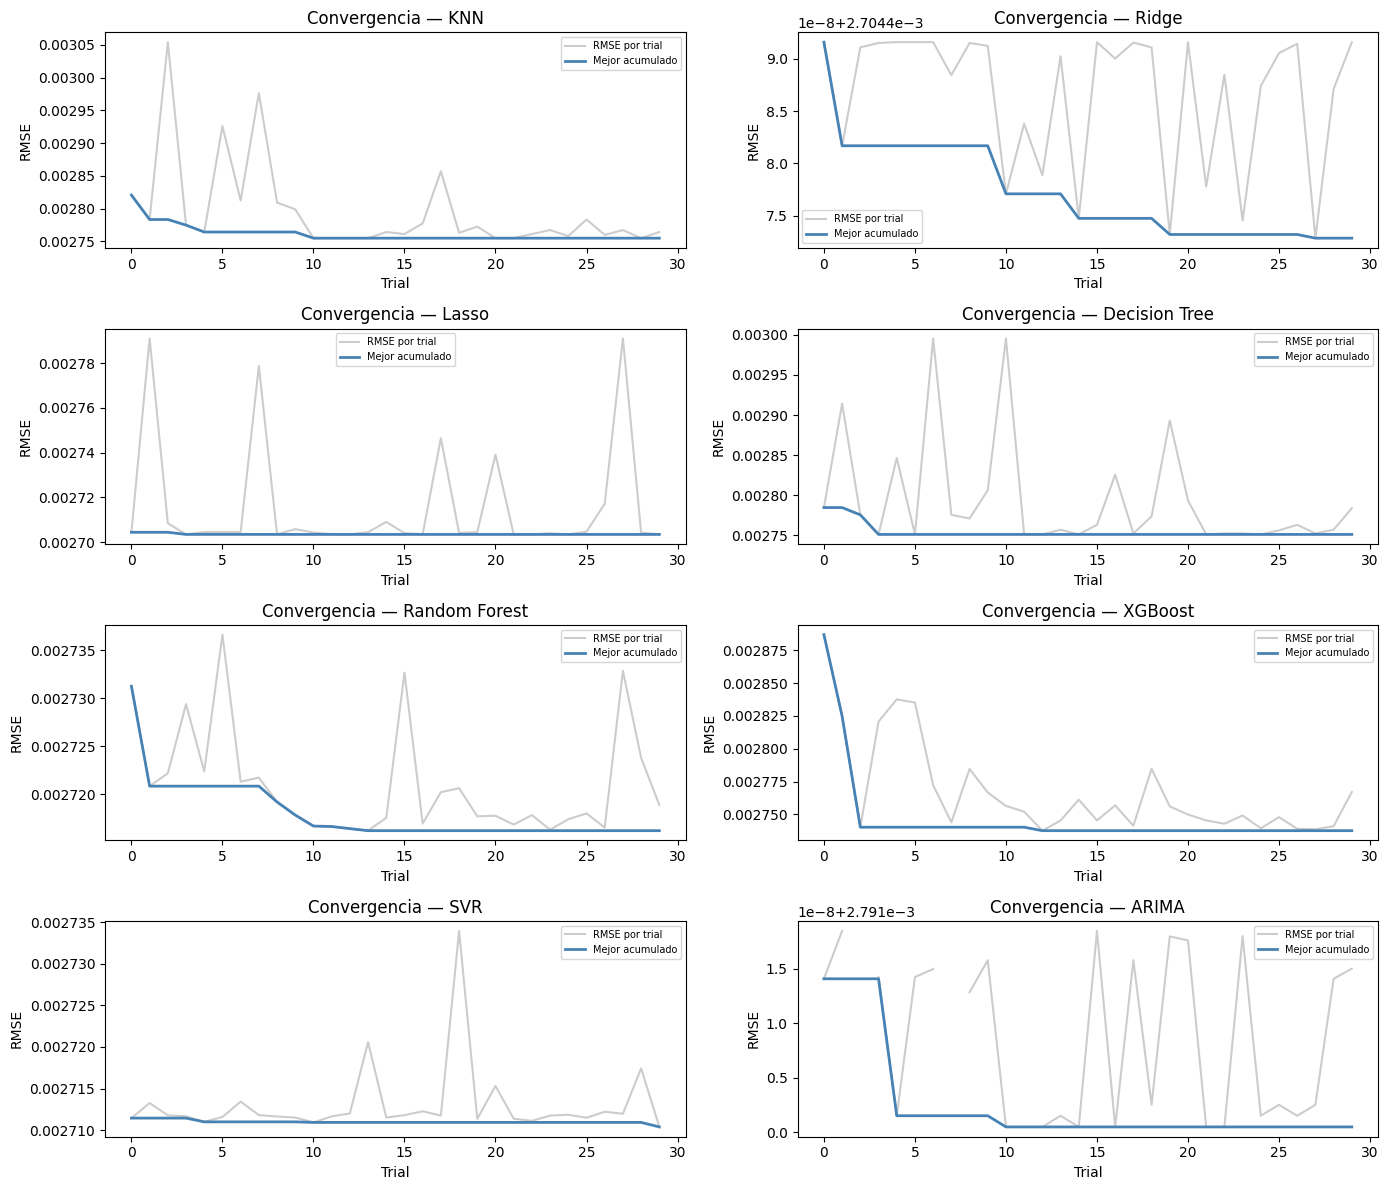

In [49]:
resultados_optuna = {}

for nombre, ModelClass in modelos.items():
    t0 = time.time()

    def objective(trial):
        if nombre == 'ARIMA':
            params = {
                'p': trial.suggest_int('p', 0, 4),
                'd': 0,
                'q': trial.suggest_int('q', 0, 4)
            }
            if params['p'] == 0 and params['q'] == 0:
                return np.inf
        elif nombre == 'KNN':
            params = {
                'n_neighbors': trial.suggest_int('n_neighbors', 2, 20),
                'weights'    : trial.suggest_categorical('weights', ['uniform', 'distance'])
            }
        elif nombre == 'Ridge':
            params = {'alpha': trial.suggest_float('alpha', 0.0001, 100, log=True)}
        elif nombre == 'Lasso':
            params = {'alpha': trial.suggest_float('alpha', 0.00001, 1, log=True)}
        elif nombre == 'Decision Tree':
            params = {
                'max_depth'        : trial.suggest_int('max_depth', 2, 15),
                'min_samples_split': trial.suggest_int('min_samples_split', 2, 20)
            }
        elif nombre == 'Random Forest':
            params = {
                'n_estimators': trial.suggest_int('n_estimators', 50, 300),
                'max_depth'   : trial.suggest_int('max_depth', 2, 10)
            }
        elif nombre == 'XGBoost':
            params = {
                'n_estimators' : trial.suggest_int('n_estimators', 50, 300),
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
            }
        else:  # SVR (LinearSVR)
            params = {
                'C'      : trial.suggest_float('C', 0.01, 20, log=True),
                'epsilon': trial.suggest_float('epsilon', 0.001, 0.1, log=True)
            }
        rmse, _, _ = evaluar_params(ModelClass, params, seed=RANDOM_SEED)
        return rmse

    study = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED)
    )
    study.optimize(objective, n_trials=30)

    # ARIMA: best_params de Optuna no incluye 'd' porque no es un trial param
    # se reincorpora aquí para que evaluar_params tenga el dict completo
    best_params = study.best_params
    if nombre == 'ARIMA':
        best_params = {'p': best_params['p'], 'd': 0, 'q': best_params['q']}

    rmse, mae, da = evaluar_params(ModelClass, best_params, seed=RANDOM_SEED)

    resultados_optuna[nombre] = {
        'rmse': rmse, 'mae': mae, 'da': da,
        'params': best_params, 'tiempo': round(time.time() - t0, 2),
        'iteraciones': 30,
        'history': [t.value for t in study.trials]
    }
    print(f'{nombre:15s} — RMSE: {rmse:.5f} | MAE: {mae:.5f} | '
          f'DA: {da:.3f} | Tiempo: {resultados_optuna[nombre]["tiempo"]}s')

# Gráfica de convergencia — 4 filas x 2 cols para 8 modelos (7 ML + ARIMA)
fig, axes = plt.subplots(4, 2, figsize=(14, 12))
axes = axes.flatten()

for i, nombre in enumerate(modelos.keys()):
    history  = resultados_optuna[nombre]['history']
    history  = [v if (v is not None and np.isfinite(v)) else np.inf for v in history]
    finite   = [v for v in history if np.isfinite(v)]
    best_acc = np.minimum.accumulate(history) if finite else history
    axes[i].plot(history, alpha=0.4, color='gray', label='RMSE por trial')
    axes[i].plot(best_acc, color='steelblue', linewidth=2, label='Mejor acumulado')
    axes[i].set_title(f'Convergencia — {nombre}')
    axes[i].set_xlabel('Trial')
    axes[i].set_ylabel('RMSE')
    axes[i].legend(fontsize=7)

plt.tight_layout()
plt.show()

- **KNN**  
    - En la tabla de resultados, el modelo KNN obtuvo un RMSE de 0.00275, un MAE de 0.00164 y una Direction Accuracy de 0.545. Estos resultados muestran un desempeño moderado en la predicción de los retornos del Bitcoin, aunque inferior frente a modelos como SVR o Ridge. El tiempo de ejecución fue de aproximadamente 56.54 segundos.

    - En el gráfico de convergencia se observa que el RMSE disminuye rápidamente durante los primeros trials y posteriormente se estabiliza. Esto indica que Optuna logró encontrar configuraciones adecuadas de hiperparámetros en pocas iteraciones y que posteriores evaluaciones no generaron mejoras significativas.

- **Ridge**  
    - El modelo Ridge alcanzó un RMSE de 0.00270, un MAE de 0.00160 y una Direction Accuracy de 0.569. Estos resultados reflejan un desempeño estable y competitivo, especialmente considerando que fue uno de los modelos con menor tiempo de ejecución, aproximadamente 0.47 segundos.

    - En el gráfico de convergencia se aprecia una curva bastante estable y con pocas variaciones entre trials. Esto evidencia que el modelo Ridge no es altamente sensible a cambios en hiperparámetros y mantiene un comportamiento consistente durante el proceso de optimización.

- **Lasso**  
    - Para el modelo Lasso se obtuvo un RMSE de 0.00270, un MAE de 0.00160 y una Direction Accuracy de 0.569. Los resultados fueron prácticamente iguales a los obtenidos por Ridge, mostrando una capacidad estable para modelar los retornos del Bitcoin. Además, presentó uno de los menores tiempos de ejecución con aproximadamente 0.42 segundos.

    - En el gráfico de convergencia se observa una línea de mejor RMSE acumulado muy estable desde los primeros trials. Esto indica que el modelo encontró rápidamente una configuración adecuada y que posteriores iteraciones no aportaron mejoras importantes.

- **Decision Tree**  
    - El modelo Decision Tree obtuvo un RMSE de 0.00275, un MAE de 0.00162 y una Direction Accuracy de 0.527. Estos resultados muestran un desempeño inferior respecto a otros modelos de Machine Learning evaluados. El tiempo de ejecución fue de aproximadamente 11.18 segundos.

    - En el gráfico de convergencia se observan fluctuaciones importantes entre trials, lo que indica que el desempeño del modelo cambia considerablemente dependiendo de la profundidad del árbol y de los criterios de división utilizados.

- **Random Forest**  
    - El modelo Random Forest alcanzó un RMSE de 0.00272, un MAE de 0.00160 y una Direction Accuracy de 0.561. Esto evidencia una buena capacidad predictiva y un desempeño competitivo frente a otros modelos evaluados. Sin embargo, el tiempo de ejecución fue elevado, alcanzando aproximadamente 1434.25 segundos.

    - En el gráfico de convergencia se aprecia una mejora gradual del mejor RMSE acumulado. Esto indica que el modelo necesitó explorar múltiples combinaciones de hiperparámetros antes de encontrar configuraciones cercanas al óptimo.

- **XGBoost**  
    - Para el modelo XGBoost se obtuvo un RMSE de 0.00274, un MAE de 0.00160 y una Direction Accuracy de 0.566. Estos resultados muestran un desempeño sólido en la predicción de tendencias del Bitcoin, combinado con un tiempo de ejecución relativamente bajo de aproximadamente 26.92 segundos.

    - En el gráfico de convergencia se observa una reducción rápida del RMSE durante las primeras iteraciones y posteriormente una estabilización. Esto refleja que Optuna logró encontrar hiperparámetros adecuados en una etapa temprana del proceso de optimización.

- **SVR**  
    - El modelo SVR presentó uno de los mejores desempeños generales, alcanzando un RMSE de 0.00271, un MAE de 0.00159 y una Direction Accuracy de 0.574. Esto evidencia una alta capacidad para predecir correctamente la dirección de los movimientos del Bitcoin. El tiempo de ejecución fue de aproximadamente 43.32 segundos.

    - En el gráfico de convergencia se aprecia una curva bastante estable con pocas fluctuaciones entre trials. Esto indica que el modelo mantiene un desempeño consistente incluso cuando se modifican sus hiperparámetros.

- **ARIMA**  
    - El modelo ARIMA obtuvo un RMSE de 0.00279, un MAE de 0.00163 y una Direction Accuracy de 0.506, siendo el desempeño más bajo entre los modelos evaluados. Además, presentó un tiempo de ejecución considerablemente alto de aproximadamente 375.58 segundos.

    - En el gráfico de convergencia se observan fluctuaciones importantes entre los diferentes trials evaluados. Sin embargo, el mejor RMSE acumulado mejora rápidamente en las primeras iteraciones y posteriormente se mantiene estable, lo que indica que algunas combinaciones de parámetros `p`, `d` y `q` generan diferencias significativas en el desempeño del modelo.

### Genetico (DEAP)

Los algoritmos genéticos simulan el proceso de selección natural para 
encontrar los mejores hiperparámetros. Cada individuo representa una 
combinación de hiperparámetros que se evalúa, selecciona, cruza y muta 
a lo largo de varias generaciones, convergiendo hacia mejores soluciones.

KNN             — RMSE: 0.00305 | MAE: 0.00189 | DA: 0.522 | Tiempo: 28.95s
Ridge           — RMSE: 0.00270 | MAE: 0.00160 | DA: 0.569 | Tiempo: 0.45s
Lasso           — RMSE: 0.00279 | MAE: 0.00163 | DA: 0.506 | Tiempo: 0.38s
Decision Tree   — RMSE: 0.00275 | MAE: 0.00162 | DA: 0.527 | Tiempo: 4.17s
Random Forest   — RMSE: 0.00273 | MAE: 0.00161 | DA: 0.547 | Tiempo: 24.43s
XGBoost         — RMSE: 0.00274 | MAE: 0.00161 | DA: 0.563 | Tiempo: 3.14s
SVR             — RMSE: 0.00271 | MAE: 0.00159 | DA: 0.574 | Tiempo: 68.31s
ARIMA           — RMSE: 0.00279 | MAE: 0.00163 | DA: 0.506 | Tiempo: 196.25s


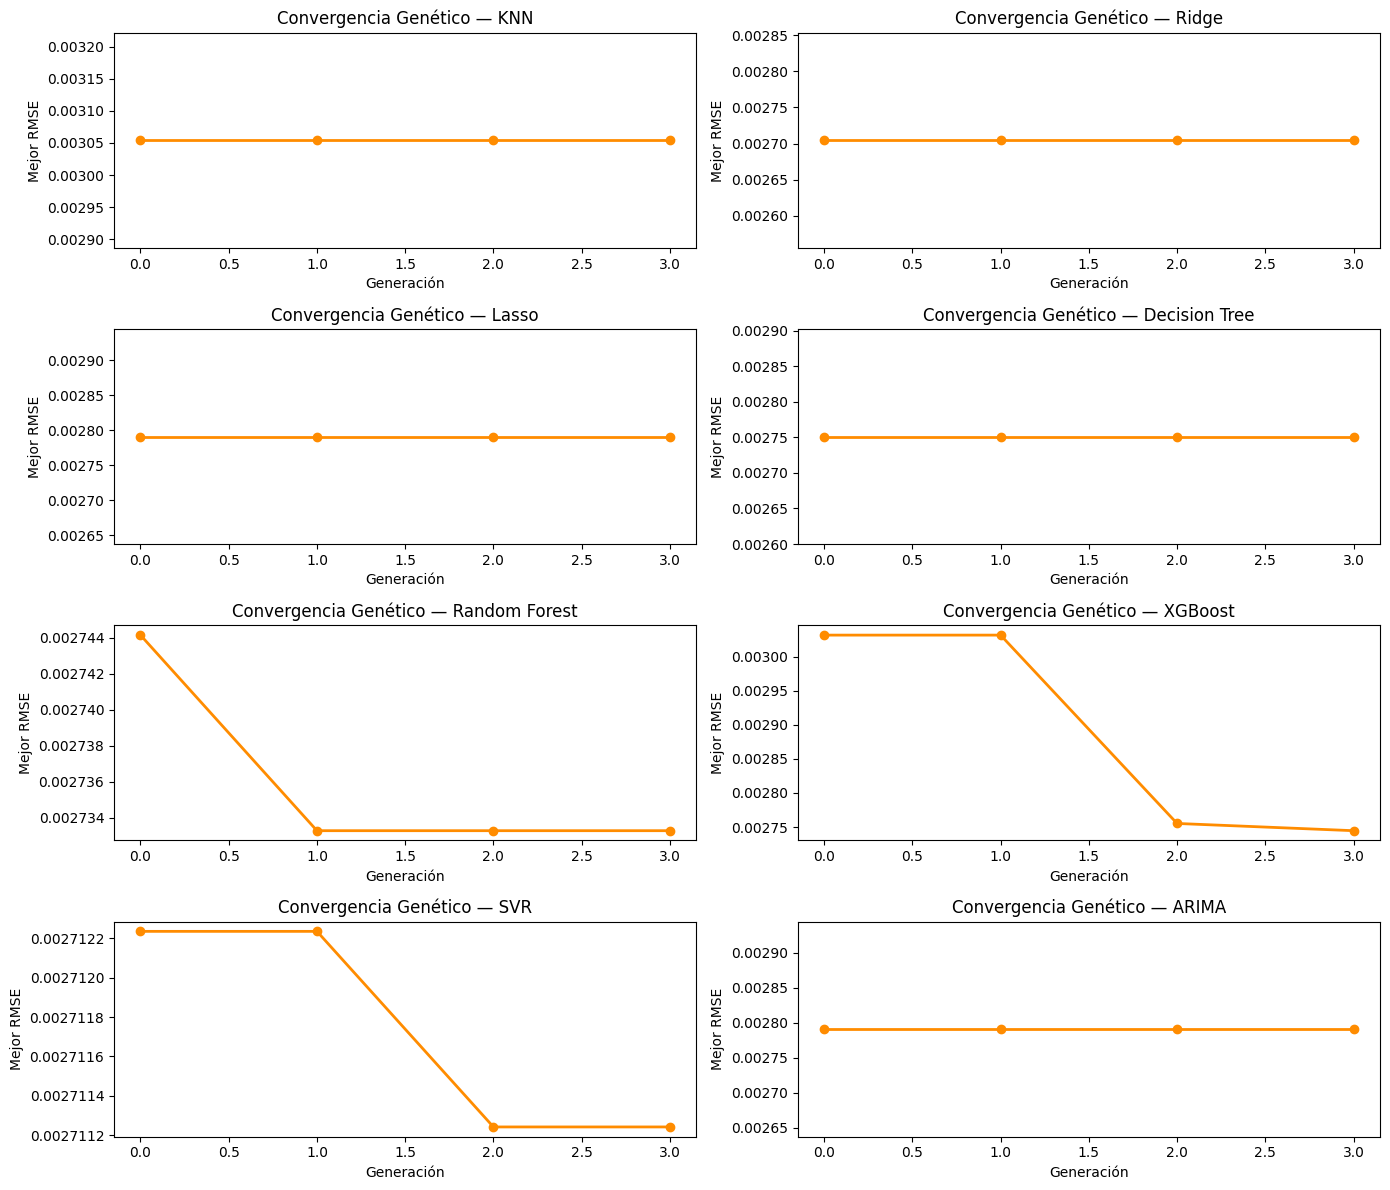

In [51]:
resultados_deap = {}

for nombre, ModelClass in modelos.items():
    t0 = time.time()
    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)

    for attr in ['FitnessMin', 'Individual']:
        if attr in creator.__dict__:
            delattr(creator, attr)

    creator.create('FitnessMin', base.Fitness, weights=(-1.0,))
    creator.create('Individual', list, fitness=creator.FitnessMin)
    toolbox = base.Toolbox()

    def decodificar(individual):
        if nombre == 'ARIMA':
            return {
                'p': max(0, min(4, int(round(abs(individual[0]))))),
                'd': 0,
                'q': max(0, min(4, int(round(abs(individual[1])))))
            }
        elif nombre == 'KNN':
            return {
                'n_neighbors': max(1, int(abs(individual[0]))),
                'weights'    : ['uniform', 'distance'][int(abs(individual[1])) % 2]
            }
        elif nombre in ['Ridge', 'Lasso']:
            return {'alpha': float(10 ** np.clip(individual[0], -5, 2))}
        elif nombre == 'Decision Tree':
            return {
                'max_depth'        : max(1, int(abs(individual[0]))),
                'min_samples_split': max(2, int(abs(individual[1])))
            }
        elif nombre == 'Random Forest':
            return {
                'n_estimators': max(10, int(abs(individual[0]))),
                'max_depth'   : max(1, int(abs(individual[1])))
            }
        elif nombre == 'XGBoost':
            return {
                'n_estimators' : max(10, int(abs(individual[0]))),
                'learning_rate': float(10 ** np.clip(individual[1], -2, 0))
            }
        else:  # SVR (LinearSVR)
            return {
                'C'      : float(10 ** np.clip(individual[0], -2, 2)),
                'epsilon': float(10 ** np.clip(individual[1], -3, -1))
            }

    def evaluar(individual):
        try:
            params = decodificar(individual)
            if nombre == 'ARIMA' and params['p'] == 0 and params['q'] == 0:
                return (999,)
            rmse, _, _ = evaluar_params(ModelClass, params, seed=RANDOM_SEED)
            return (rmse,)
        except Exception:
            return (999,)

    n_genes = 1 if nombre in ['Ridge', 'Lasso'] else 2
    toolbox.register('attr_float', random.uniform, 0, 4)
    toolbox.register('individual', tools.initRepeat,
                     creator.Individual, toolbox.attr_float, n=n_genes)
    toolbox.register('population', tools.initRepeat, list, toolbox.individual)
    toolbox.register('evaluate', evaluar)
    toolbox.register('mate',   tools.cxBlend, alpha=0.5)
    toolbox.register('mutate', tools.mutGaussian, mu=0, sigma=1, indpb=0.3)
    toolbox.register('select', tools.selTournament, tournsize=3)

    pop   = toolbox.population(n=10)
    hof   = tools.HallOfFame(1)
    stats = tools.Statistics(
        lambda ind: ind.fitness.values[0] if ind.fitness.valid else 999
    )
    stats.register('min', np.min)

    pop, log = algorithms.eaSimple(
        pop, toolbox, cxpb=0.5, mutpb=0.3,
        ngen=3, stats=stats, halloffame=hof, verbose=False
    )

    best_params = decodificar(hof[0])
    rmse, mae, da = evaluar_params(ModelClass, best_params, seed=RANDOM_SEED)

    resultados_deap[nombre] = {
        'rmse': rmse, 'mae': mae, 'da': da,
        'params': best_params, 'tiempo': round(time.time() - t0, 2),
        'iteraciones': 30,
        'history': [gen['min'] for gen in log]
    }
    print(f'{nombre:15s} — RMSE: {rmse:.5f} | MAE: {mae:.5f} | '
          f'DA: {da:.3f} | Tiempo: {resultados_deap[nombre]["tiempo"]}s')

# Gráfica convergencia genético — 4x2 para 8 modelos
fig, axes = plt.subplots(4, 2, figsize=(14, 12))
axes = axes.flatten()

for i, nombre in enumerate(modelos.keys()):
    axes[i].plot(resultados_deap[nombre]['history'],
                 marker='o', color='darkorange', linewidth=2)
    axes[i].set_title(f'Convergencia Genético — {nombre}')
    axes[i].set_xlabel('Generación')
    axes[i].set_ylabel('Mejor RMSE')

plt.tight_layout()
plt.show()


- **KNN**  
    - En la tabla de resultados, el modelo KNN obtuvo un RMSE de 0.00305, un MAE de 0.00189 y una Direction Accuracy de 0.522. Estos resultados muestran un desempeño inferior respecto a otros métodos de optimización aplicados previamente. El tiempo de ejecución fue de aproximadamente 28.95 segundos.

    - En el gráfico de convergencia genética se observa una línea completamente estable a lo largo de las generaciones. Esto indica que el algoritmo genético no logró encontrar mejoras adicionales en los hiperparámetros evaluados para este modelo.

- **Ridge**  
    - El modelo Ridge alcanzó un RMSE de 0.00270, un MAE de 0.00160 y una Direction Accuracy de 0.569. Estos resultados reflejan un desempeño sólido y consistente, manteniéndose entre los mejores modelos evaluados. Además, presentó un tiempo de ejecución muy bajo de aproximadamente 0.45 segundos.

    - En el gráfico de convergencia genética se observa un comportamiento completamente estable entre generaciones. Esto evidencia que el modelo encontró rápidamente una solución adecuada y que posteriores generaciones no produjeron mejoras relevantes.

- **Lasso**  
    - Para el modelo Lasso se obtuvo un RMSE de 0.00279, un MAE de 0.00163 y una Direction Accuracy de 0.506. Estos resultados muestran un desempeño inferior comparado con Ridge y otros modelos más robustos. El tiempo de ejecución fue de aproximadamente 0.38 segundos.

    - En el gráfico de convergencia genética se aprecia una línea prácticamente constante entre generaciones. Esto indica que el algoritmo genético encontró rápidamente una solución estable sin variaciones importantes durante la optimización.

- **Decision Tree**  
    - El modelo Decision Tree obtuvo un RMSE de 0.00275, un MAE de 0.00162 y una Direction Accuracy de 0.527. Estos resultados reflejan un desempeño moderado en comparación con otros modelos de Machine Learning. El tiempo de ejecución fue de aproximadamente 4.17 segundos.

    - En el gráfico de convergencia genética se observa una estabilidad completa del mejor RMSE a lo largo de las generaciones. Esto sugiere que las configuraciones evaluadas no generaron mejoras significativas en el desempeño del modelo.

- **Random Forest**  
    - El modelo Random Forest alcanzó un RMSE de 0.00273, un MAE de 0.00161 y una Direction Accuracy de 0.547. Aunque el desempeño fue competitivo, continuó presentando un costo computacional relativamente alto con un tiempo de ejecución cercano a 24.43 segundos.

    - En el gráfico de convergencia genética se aprecia una mejora del RMSE durante las primeras generaciones y posteriormente una estabilización. Esto indica que el algoritmo genético logró optimizar parcialmente los hiperparámetros antes de converger hacia una solución estable.

- **XGBoost**  
    - Para el modelo XGBoost se obtuvo un RMSE de 0.00274, un MAE de 0.00161 y una Direction Accuracy de 0.563. Estos resultados muestran un desempeño sólido y competitivo en la predicción de tendencias del Bitcoin. El tiempo de ejecución fue de aproximadamente 3.14 segundos.

    - En el gráfico de convergencia genética se observa una reducción importante del RMSE a partir de las primeras generaciones y luego una estabilización progresiva. Esto evidencia que el algoritmo genético logró mejorar significativamente los hiperparámetros iniciales del modelo.

- **SVR**  
    - El modelo SVR presentó uno de los mejores desempeños generales, alcanzando un RMSE de 0.00271, un MAE de 0.00159 y una Direction Accuracy de 0.574. Esto evidencia una alta capacidad para predecir correctamente la dirección de los movimientos del Bitcoin. El tiempo de ejecución fue de aproximadamente 68.31 segundos.

    - En el gráfico de convergencia genética se aprecia una ligera mejora del RMSE en generaciones posteriores seguida de una estabilización. Esto indica que el algoritmo genético logró refinar gradualmente los hiperparámetros hasta encontrar una solución cercana al óptimo.

- **ARIMA**  
    - El modelo ARIMA obtuvo un RMSE de 0.00279, un MAE de 0.00163 y una Direction Accuracy de 0.506, siendo nuevamente uno de los desempeños más bajos entre los modelos evaluados. Además, el tiempo de ejecución fue elevado, alcanzando aproximadamente 196.25 segundos.

    - En el gráfico de convergencia genética se observa una línea prácticamente constante entre generaciones. Esto indica que el algoritmo genético no logró encontrar mejoras relevantes en las combinaciones de parámetros `p`, `d` y `q` evaluadas para el modelo.

### Tabla comparativa final

Comparación de los cuatro métodos de optimización por modelo, evaluando 
RMSE, MAE, Direction Accuracy, tiempo de ejecución e iteraciones.

In [56]:
filas = []
for nombre in modelos.keys():
    for metodo, resultados in [('Grid Search',  resultados_grid),
                                ('Random Search', resultados_random),
                                ('Bayesiana',     resultados_optuna),
                                ('Genético',      resultados_deap)]:
        filas.append({
            'Modelo'     : nombre,
            'Método'     : metodo,
            'RMSE'       : round(resultados[nombre]['rmse'], 5),
            'MAE'        : round(resultados[nombre]['mae'], 5),
            'DA'         : round(resultados[nombre]['da'], 3),
            'Tiempo (s)' : resultados[nombre]['tiempo'],
            'Iteraciones': resultados[nombre]['iteraciones']
        })

tabla = pd.DataFrame(filas)

# Highlight mejor RMSE por modelo
def highlight_best(df):
    styled = df.style\
        .background_gradient(subset=['RMSE'], cmap='RdYlGn_r')\
        .background_gradient(subset=['DA'],   cmap='RdYlGn')\
        .background_gradient(subset=['MAE'],  cmap='RdYlGn_r')\
        .format({
            'RMSE'      : '{:.5f}',
            'MAE'       : '{:.5f}',
            'DA'        : '{:.3f}',
            'Tiempo (s)': '{:.2f}'
        })\
        .set_table_styles([
            {'selector': 'thead th',
             'props': [('background-color', '#2c3e50'),
                       ('color', 'white'),
                       ('font-weight', 'bold'),
                       ('text-align', 'center'),
                       ('padding', '8px')]},
            {'selector': 'tbody td',
             'props': [('text-align', 'center'),
                       ('padding', '6px')]},
            {'selector': 'tbody tr:hover',
             'props': [('background-color', '#f0f4f8')]},
        ])\
        .hide(axis='index')
    return styled

highlight_best(tabla)

Modelo,Método,RMSE,MAE,DA,Tiempo (s),Iteraciones
KNN,Grid Search,0.00277,0.00166,0.541,14.57,10
KNN,Random Search,0.00276,0.00165,0.544,48.63,30
KNN,Bayesiana,0.00275,0.00164,0.545,56.54,30
KNN,Genético,0.00305,0.00189,0.522,28.95,30
Ridge,Grid Search,0.00270,0.00160,0.569,0.10,6
Ridge,Random Search,0.00270,0.00160,0.569,0.52,30
Ridge,Bayesiana,0.00270,0.00160,0.569,0.47,30
Ridge,Genético,0.00270,0.00160,0.569,0.45,30
Lasso,Grid Search,0.00270,0.00160,0.569,0.07,5
Lasso,Random Search,0.00271,0.00160,0.567,0.45,30


Al comparar los resultados obtenidos entre los diferentes modelos y métodos de optimización, se observa que los modelos lineales como Ridge y Lasso mantuvieron un desempeño bastante estable en prácticamente todos los escenarios evaluados. Ambos alcanzaron consistentemente valores de RMSE cercanos a 0.00270 y Direction Accuracy alrededor de 0.569, además de presentar los menores tiempos de ejecución. Esto demuestra que son modelos eficientes computacionalmente y poco sensibles a cambios en los hiperparámetros.

Por otro lado, el modelo SVR presentó uno de los mejores desempeños generales del proyecto. En varios métodos de optimización logró alcanzar un RMSE de aproximadamente 0.00271 y una Direction Accuracy de hasta 0.574, siendo uno de los valores más altos obtenidos. Esto evidencia una alta capacidad para capturar patrones complejos y predecir correctamente la dirección de los movimientos del Bitcoin. Sin embargo, el costo computacional fue considerablemente mayor que el de modelos lineales como Ridge o Lasso.

XGBoost también mostró resultados bastante competitivos, especialmente en términos de Direction Accuracy, alcanzando valores cercanos a 0.575. Además, presentó tiempos de ejecución moderados en comparación con Random Forest y SVR, lo que lo convierte en una alternativa balanceada entre desempeño predictivo y eficiencia computacional.

En el caso de Random Forest, el modelo logró buenos resultados en RMSE y Direction Accuracy, manteniéndose competitivo frente a otros modelos avanzados. No obstante, fue uno de los modelos con mayor costo computacional, especialmente en métodos como Random Search y Bayesian Optimization, donde los tiempos de ejecución superaron ampliamente al resto de modelos evaluados.

Decision Tree mostró un desempeño moderado en todas las pruebas realizadas. Aunque logró resultados aceptables, presentó una menor estabilidad y una Direction Accuracy inferior frente a modelos más robustos como SVR, Ridge o XGBoost.

El modelo KNN presentó resultados variables dependiendo del método de optimización utilizado. Aunque en algunos casos logró métricas competitivas, en otros métodos como el algoritmo genético mostró una reducción importante en el desempeño, indicando una mayor sensibilidad a la selección de hiperparámetros.

Finalmente, ARIMA fue el modelo con menor desempeño general en la mayoría de las métricas evaluadas. Aunque es ampliamente utilizado en problemas de series temporales, presentó dificultades para modelar adecuadamente la volatilidad y comportamiento no lineal de los retornos del Bitcoin. Además, sus tiempos de ejecución fueron relativamente altos en comparación con el desempeño obtenido.

En términos de métodos de optimización, Grid Search y Bayesian Optimization fueron los que presentaron los resultados más estables y competitivos en la mayoría de modelos. Random Search permitió explorar espacios de búsqueda más amplios, aunque con un mayor costo computacional en ciertos modelos. Por su parte, el algoritmo genético mostró mejoras importantes en algunos casos específicos como XGBoost y SVR, aunque en modelos más simples no logró aportar ventajas significativas.

De manera general, los resultados obtenidos evidencian que modelos como SVR, XGBoost y Ridge ofrecieron el mejor equilibrio entre capacidad predictiva, estabilidad y precisión en la predicción de los retornos del Bitcoin.

## Analisis de residuos

Se analizan los residuos del mejor modelo general. Un buen modelo debe 
dejar residuos sin patrón, independientes y sin autocorrelación. Se 
aplican el test de Ljung-Box para detectar autocorrelación lineal y el 
test BDS para dependencia no lineal.

Hiperparámetros seleccionados para análisis de residuos:
Modelo          Método          RMSE       Parámetros
────────────────────────────────────────────────────────────────────────────────
KNN             Bayesiana       0.00275    {'n_neighbors': 20, 'weights': 'uniform'}
Ridge           Grid Search     0.00270    {'alpha': 100.0}
Lasso           Bayesiana       0.00270    {'alpha': 0.010129197956845729}
Decision Tree   Random Search   0.00275    {'max_depth': 2, 'min_samples_split': 2}
Random Forest   Random Search   0.00272    {'n_estimators': 197, 'max_depth': 5}
XGBoost         Grid Search     0.00274    {'n_estimators': 100, 'learning_rate': 0.01}
SVR             Random Search   0.00271    {'C': np.float64(4.1883743523072035), 'epsilon': np.float64(0.03355717584120253)}
ARIMA           Random Search   0.00279    {'p': 4, 'd': 0, 'q': 3}


Modelo,Método,Ljung-Box p,LB Conclusion,BDS p,BDS Conclusion,White p,White Conclusion,JB p,JB Conclusion,SW p,SW Conclusion
KNN,Bayesiana,2.50e-02,Autocorrelacion,5.63e-14,Dep. no lineal,1.29e-197,Heterocedastico,0.00e+00,No normal,9.60e-63,No normal
Ridge,Grid Search,1.10e-02,Autocorrelacion,2.61e-14,Dep. no lineal,0.00e+00,Heterocedastico,0.00e+00,No normal,2.49e-61,No normal
Lasso,Bayesiana,9.75e-03,Autocorrelacion,2.32e-14,Dep. no lineal,0.00e+00,Heterocedastico,0.00e+00,No normal,1.48e-61,No normal
Decision Tree,Random Search,9.95e-03,Autocorrelacion,9.85e-16,Dep. no lineal,1.01e-285,Heterocedastico,0.00e+00,No normal,5.83e-60,No normal
Random Forest,Random Search,1.56e-02,Autocorrelacion,1.26e-16,Dep. no lineal,1.70e-300,Heterocedastico,0.00e+00,No normal,3.15e-60,No normal
XGBoost,Grid Search,2.35e-02,Autocorrelacion,1.70e-16,Dep. no lineal,2.50e-16,Heterocedastico,0.00e+00,No normal,1.50e-63,No normal
SVR,Random Search,3.17e-02,Autocorrelacion,2.89e-13,Dep. no lineal,0.00e+00,Heterocedastico,0.00e+00,No normal,4.96e-62,No normal
ARIMA,Random Search,5.76e-02,Independientes,2.98e-12,Dep. no lineal,4.27e-01,Homocedastico,0.00e+00,No normal,2.88e-64,No normal


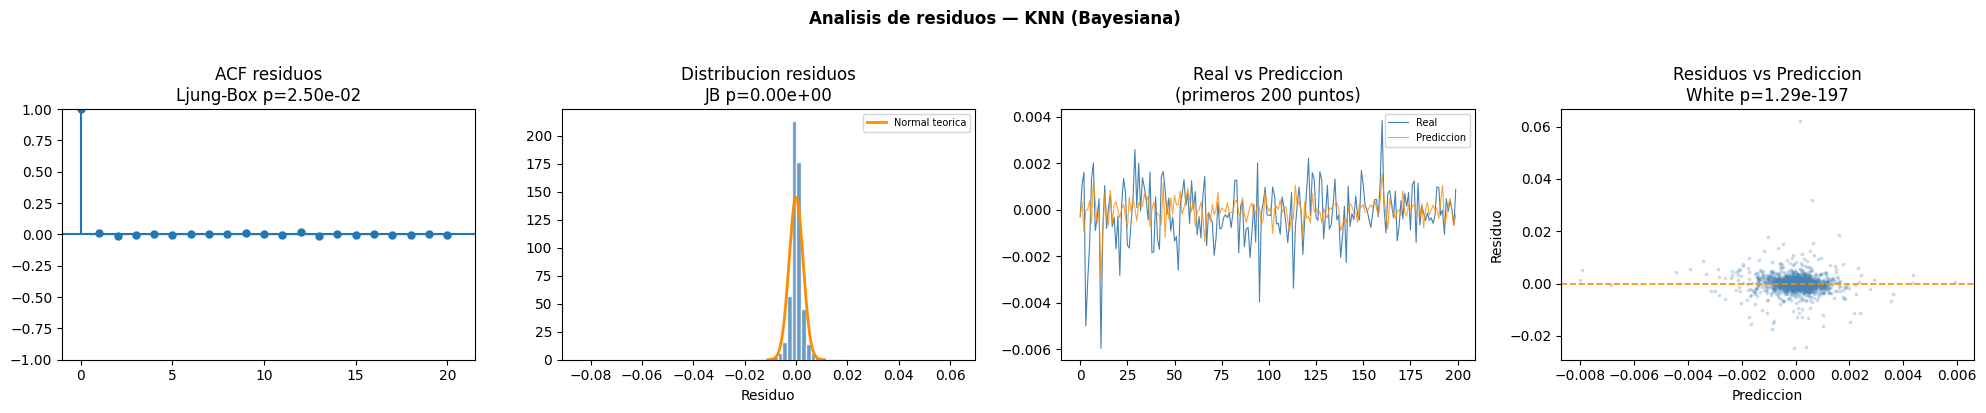

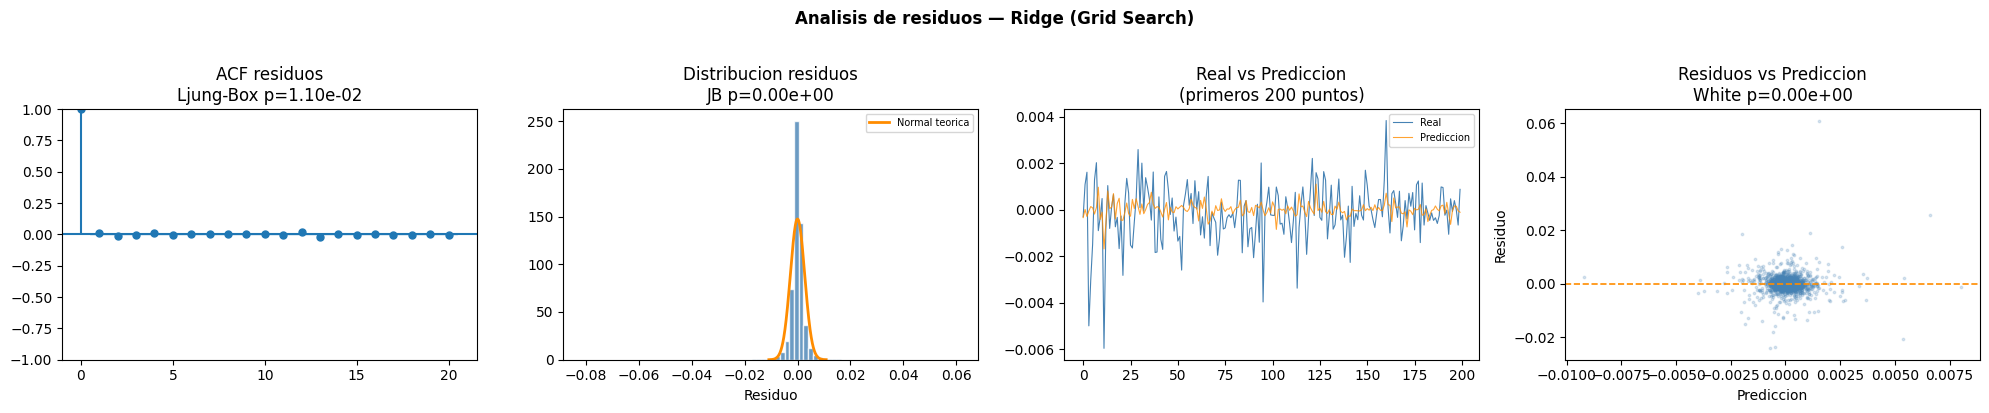

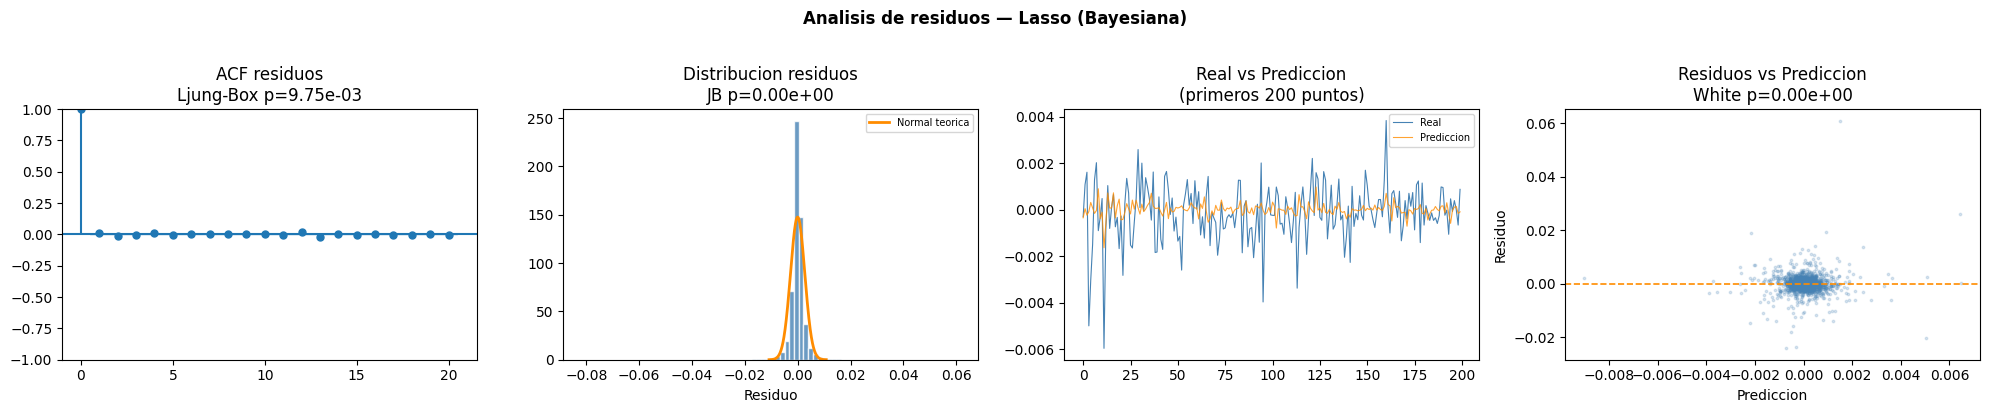

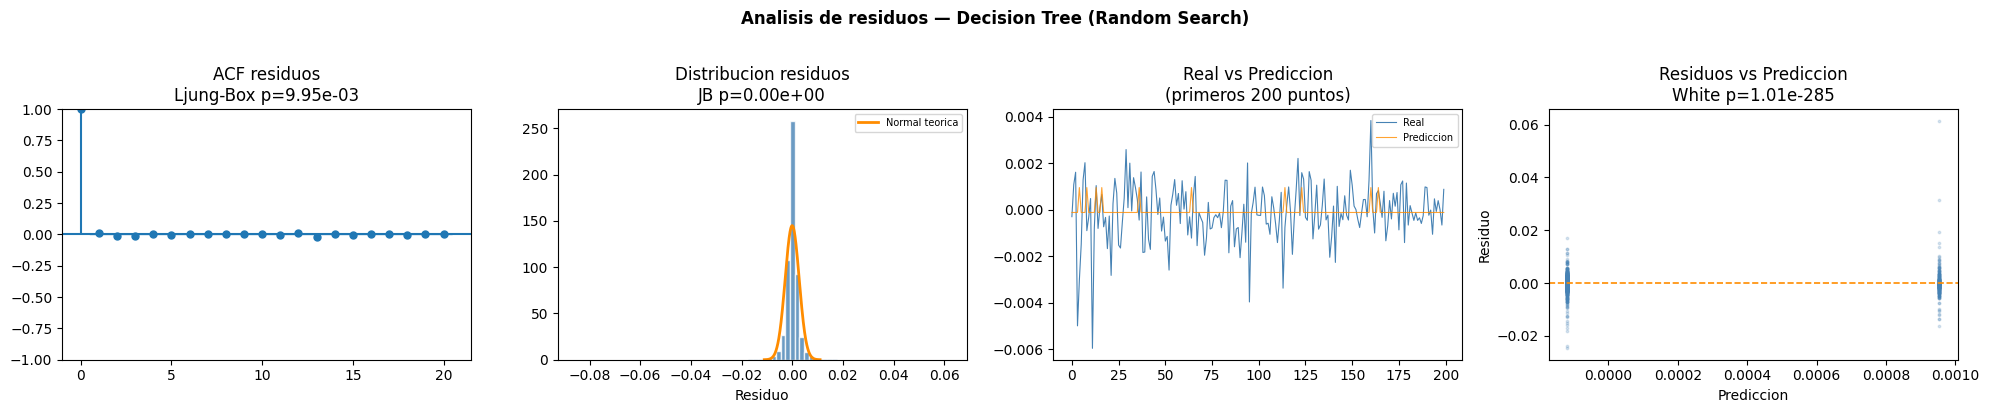

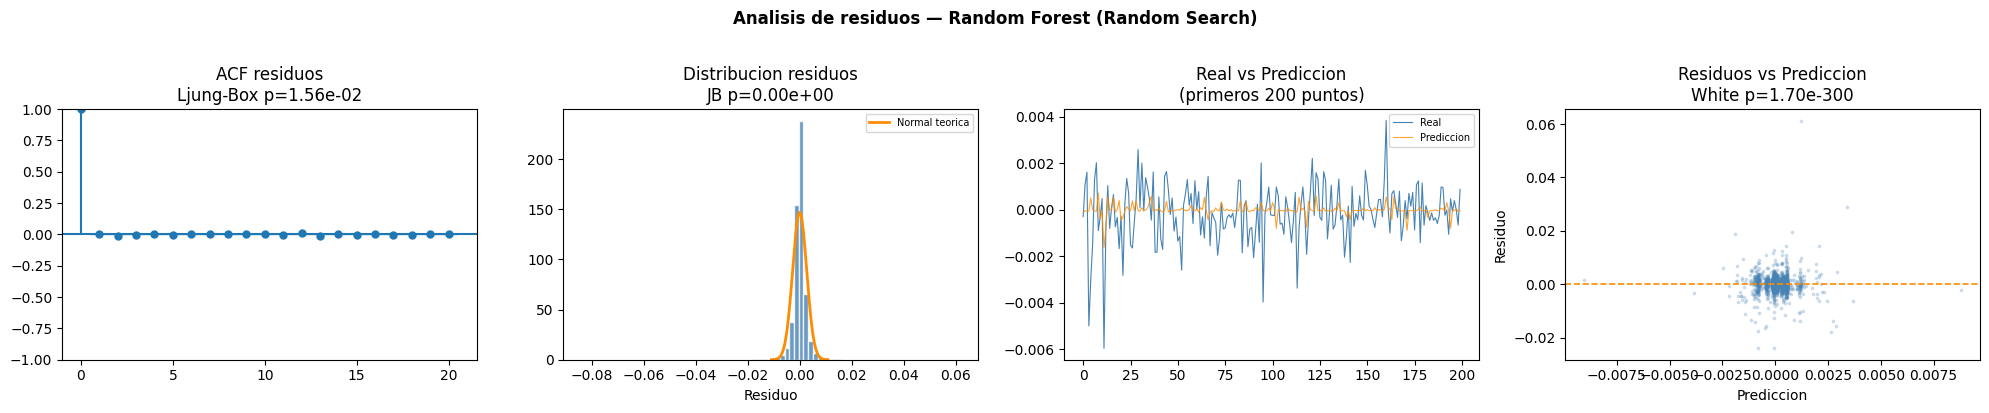

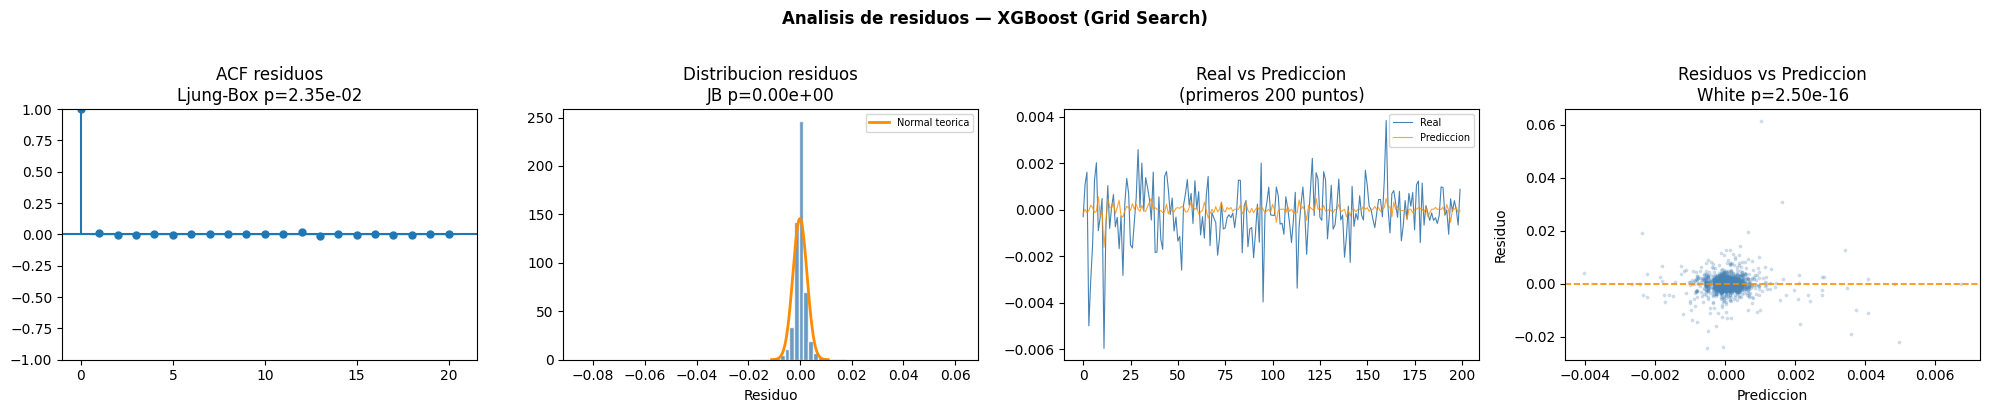

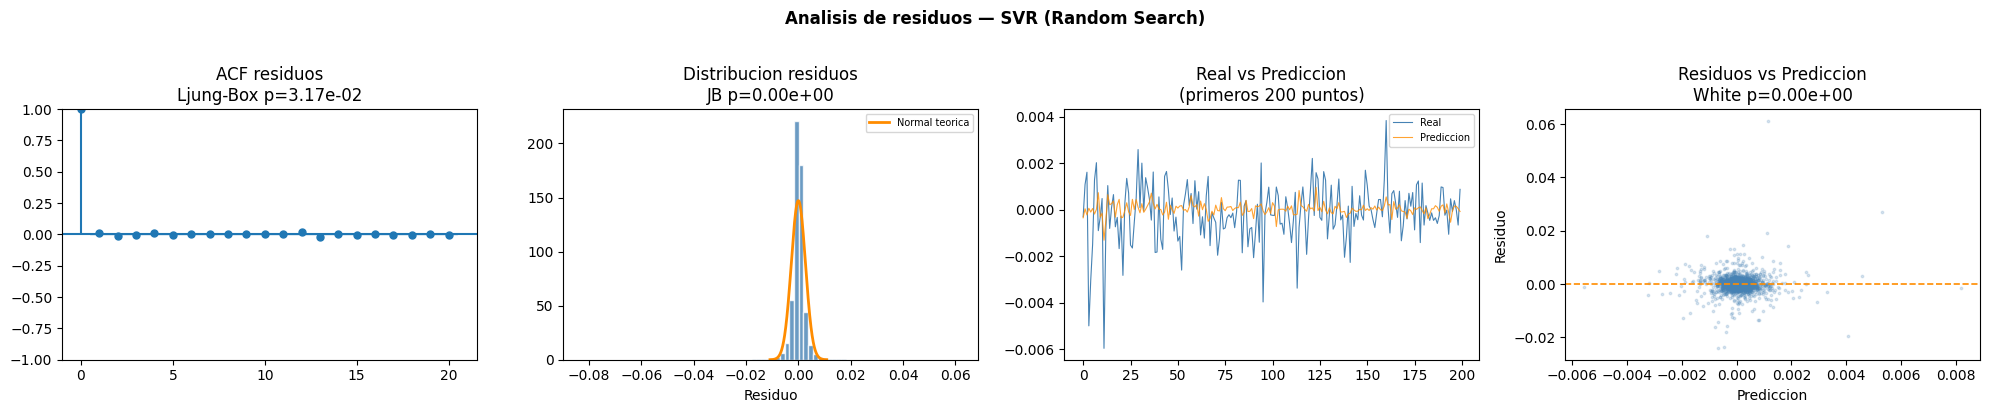

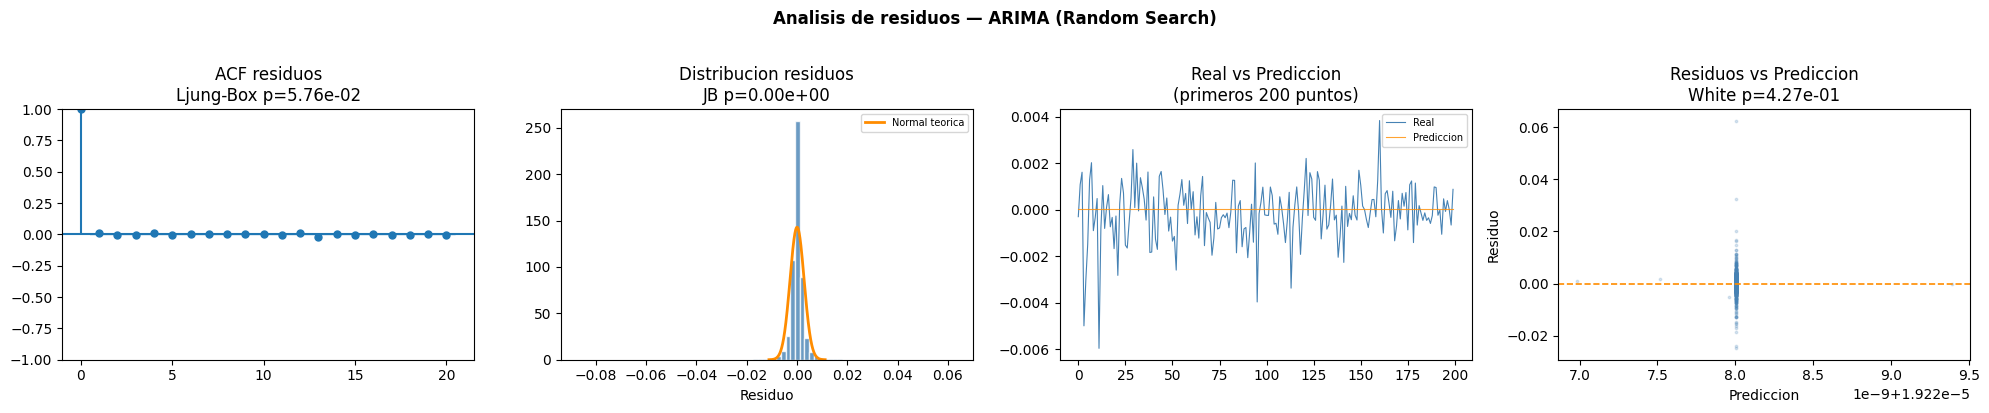

In [84]:
from statsmodels.stats.diagnostic import het_white
from scipy.stats import shapiro, jarque_bera
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

# ─────────────────────────────────────────────────────────────────────────────
# Seleccionar mejores hiperparámetros por modelo (mejor método por RMSE)
# ─────────────────────────────────────────────────────────────────────────────
mejor_por_modelo  = {}
metodo_por_modelo = {}

for nombre in modelos.keys():
    mejor = min(
        [('Grid Search',   resultados_grid),
         ('Random Search', resultados_random),
         ('Bayesiana',     resultados_optuna),
         ('Genetico',      resultados_deap)],
        key=lambda x: x[1][nombre]['rmse']
    )
    metodo_por_modelo[nombre] = mejor[0]
    mejor_por_modelo[nombre]  = mejor[1][nombre]['params']

print('Hiperparámetros seleccionados para análisis de residuos:')
print(f'{"Modelo":15} {"Método":15} {"RMSE":10} {"Parámetros"}')
print('─' * 80)
for nombre in modelos.keys():
    rmse = min(r[nombre]['rmse'] for r in [resultados_grid, resultados_random,
                                            resultados_optuna, resultados_deap])
    print(f'{nombre:15} {metodo_por_modelo[nombre]:15} {rmse:.5f}    '
          f'{mejor_por_modelo[nombre]}')

# ─────────────────────────────────────────────────────────────────────────────
# Recolectar residuos y predicciones para todos los modelos
# ─────────────────────────────────────────────────────────────────────────────
residuos_por_modelo  = {}
preds_por_modelo_res = {}
real_comun_res       = None

for nombre, ModelClass in modelos.items():
    params     = mejor_por_modelo[nombre]
    residuos_m = []
    preds_m    = []
    real_m     = []

    for fold in range(len(X)):
        X_train_raw = X[fold].reshape(X[fold].shape[0], -1)
        X_test_raw  = Xtest[fold].reshape(Xtest[fold].shape[0], -1)
        y_train_raw = y[fold].reshape(y[fold].shape[0], -1)
        y_test_raw  = ytest[fold].ravel()

        if nombre == 'ARIMA':
            try:
                fit  = ARIMA(y_train_raw.ravel(),
                             order=(params['p'], params['d'], params['q'])).fit()
                yhat = fit.forecast(steps=len(y_test_raw))
            except Exception:
                yhat = np.zeros(len(y_test_raw))
        else:
            scaler_x = StandardScaler().fit(X_train_raw)
            scaler_y = StandardScaler().fit(y_train_raw)
            X_train  = scaler_x.transform(X_train_raw)
            X_test_  = scaler_x.transform(X_test_raw)
            y_train  = scaler_y.transform(y_train_raw).ravel()
            try:
                model = ModelClass(**params, random_state=RANDOM_SEED)
            except Exception:
                model = ModelClass(**params)
            model.fit(X_train, y_train)
            yhat = scaler_y.inverse_transform(
                model.predict(X_test_).reshape(-1, 1)
            ).ravel()

        residuos_m.extend(y_test_raw - yhat)
        preds_m.extend(yhat)
        real_m.extend(y_test_raw)

    residuos_por_modelo[nombre]  = np.array(residuos_m)
    preds_por_modelo_res[nombre] = np.array(preds_m)
    if real_comun_res is None:
        real_comun_res = np.array(real_m)

# ─────────────────────────────────────────────────────────────────────────────
# Calcular tests para cada modelo
# ─────────────────────────────────────────────────────────────────────────────
filas_tests = []

for nombre in modelos.keys():
    res  = residuos_por_modelo[nombre]
    pred = preds_por_modelo_res[nombre]

    lb_p    = acorr_ljungbox(res, lags=[10], return_df=True)['lb_pvalue'].values[0]
    bds_p   = bds(res[:2000], max_dim=2)[1].item()
    try:
        X_w = np.column_stack([np.ones(len(pred)), pred, pred**2])
        _, white_p, _, _ = het_white(res, X_w)
    except AssertionError:
        X_bp = np.column_stack([np.ones(len(pred)), pred])
        _, white_p, _, _ = het_breuschpagan(res, X_bp)
    _, jb_p = jarque_bera(res)
    _, sw_p = shapiro(res[:5000])

    filas_tests.append({
        'Modelo'          : nombre,
        'Método'          : metodo_por_modelo[nombre],
        'Ljung-Box p'     : f'{lb_p:.2e}',
        'LB Conclusion'   : 'Independientes'     if lb_p    > 0.05 else 'Autocorrelacion',
        'BDS p'           : f'{bds_p:.2e}',
        'BDS Conclusion'  : 'Sin dep. no lineal' if bds_p   > 0.05 else 'Dep. no lineal',
        'White p'         : f'{white_p:.2e}',
        'White Conclusion': 'Homocedastico'      if white_p > 0.05 else 'Heterocedastico',
        'JB p'            : f'{jb_p:.2e}',
        'JB Conclusion'   : 'Normal'             if jb_p    > 0.05 else 'No normal',
        'SW p'            : f'{sw_p:.2e}',
        'SW Conclusion'   : 'Normal'             if sw_p    > 0.05 else 'No normal',
    })

df_tests = pd.DataFrame(filas_tests)

# ─────────────────────────────────────────────────────────────────────────────
# Tabla consolidada de tests
# ─────────────────────────────────────────────────────────────────────────────
def highlight_tests(df):
    def color_concl(val):
        if not isinstance(val, str): return ''
        positivos = {'Independientes', 'Sin dep. no lineal',
                     'Homocedastico', 'Normal'}
        return 'color: #2ecc71' if val in positivos else 'color: #e74c3c'

    def color_pval(val):
        if isinstance(val, str):
            try:
                return 'color: #2ecc71' if float(val) > 0.05 else 'color: #e74c3c'
            except ValueError:
                return ''
        return ''

    concl_cols = ['LB Conclusion', 'BDS Conclusion',
                  'White Conclusion', 'JB Conclusion', 'SW Conclusion']
    pval_cols  = ['Ljung-Box p', 'BDS p', 'White p', 'JB p', 'SW p']

    return df.style\
        .map(color_concl, subset=concl_cols)\
        .map(color_pval,  subset=pval_cols)\
        .set_caption('Analisis de residuos — todos los modelos')\
        .set_table_styles([
            {'selector': 'caption',
             'props': [('font-size', '13px'),
                       ('font-weight', 'bold'),
                       ('padding-bottom', '8px')]},
            {'selector': 'thead th',
             'props': [('background-color', '#2c3e50'),
                       ('color', 'white'),
                       ('font-weight', 'bold'),
                       ('text-align', 'center'),
                       ('padding', '8px')]},
            {'selector': 'tbody td',
             'props': [('text-align', 'center'),
                       ('padding', '6px')]},
            {'selector': 'tbody tr:nth-child(even)',
             'props': [('background-color', '#293138')]},
        ])\
        .hide(axis='index')

display(highlight_tests(df_tests))

# ─────────────────────────────────────────────────────────────────────────────
# Graficas — 4 plots por modelo
# ─────────────────────────────────────────────────────────────────────────────
for nombre in modelos.keys():
    res  = residuos_por_modelo[nombre]
    pred = preds_por_modelo_res[nombre]
    real = real_comun_res

    row  = df_tests[df_tests['Modelo'] == nombre].iloc[0]
    lb_p    = row['Ljung-Box p']
    jb_p    = row['JB p']
    white_p = row['White p']

    fig, axes = plt.subplots(1, 4, figsize=(20, 4))

    # ACF
    plot_acf(res, lags=20, ax=axes[0], alpha=0.05)
    axes[0].set_title(f'ACF residuos\nLjung-Box p={lb_p}')

    # Histograma + normal teorica
    mu, sigma = res.mean(), res.std()
    axes[1].hist(res, bins=80, color='steelblue', edgecolor='white',
                 density=True, alpha=0.8)
    x_norm = np.linspace(mu - 4*sigma, mu + 4*sigma, 300)
    axes[1].plot(x_norm, stats.norm.pdf(x_norm, mu, sigma),
                 color='darkorange', linewidth=2, label='Normal teorica')
    axes[1].set_title(f'Distribucion residuos\nJB p={jb_p}')
    axes[1].set_xlabel('Residuo')
    axes[1].legend(fontsize=7)

    # Real vs Prediccion
    axes[2].plot(real[:200],  label='Real',       color='steelblue',  linewidth=0.8)
    axes[2].plot(pred[:200],  label='Prediccion', color='darkorange', linewidth=0.8, alpha=0.8)
    axes[2].set_title('Real vs Prediccion\n(primeros 200 puntos)')
    axes[2].legend(fontsize=7)

    # Residuos vs Prediccion — heterocedasticidad visual
    axes[3].scatter(pred[:2000], res[:2000], alpha=0.2, s=3, color='steelblue')
    axes[3].axhline(0, color='darkorange', linewidth=1.2, linestyle='--')
    axes[3].set_title(f'Residuos vs Prediccion\nWhite p={white_p}')
    axes[3].set_xlabel('Prediccion')
    axes[3].set_ylabel('Residuo')

    plt.suptitle(f'Analisis de residuos — {nombre} ({metodo_por_modelo[nombre]})',
                 fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# Exportar
df_tests.to_csv('outputs/residuos_tests.csv', index=False)


- **KNN**
    - **Interpretación de la tabla**  
    El modelo KNN optimizado mediante Bayesian Optimization presentó un p valor de 2.50e-02 en la prueba de Ljung Box, indicando presencia de autocorrelación en los residuos. Además, la prueba BDS mostró dependencia no lineal, mientras que la prueba White evidenció heterocedasticidad. Finalmente, tanto Jarque Bera como Shapiro Wilk rechazaron la hipótesis de normalidad, indicando que los residuos no siguen una distribución normal.

    - **ACF residuos**  
    En el gráfico ACF se observa que la mayoría de autocorrelaciones se mantienen cerca de cero después del primer rezago. Esto indica que el modelo logró reducir gran parte de la dependencia temporal presente en la serie, aunque todavía existen pequeñas correlaciones residuales.

    - **Distribución residuos**  
    El histograma de residuos muestra una fuerte concentración alrededor de cero, aunque con colas más pronunciadas que la distribución normal teórica. Esto evidencia presencia de valores extremos y desviaciones respecto a la normalidad.

    - **Real vs Predicción**  
    En el gráfico de valores reales contra predicciones se aprecia que el modelo logra seguir parcialmente la tendencia general de la serie, aunque suaviza considerablemente los movimientos más bruscos del Bitcoin.

    - **Residuos vs Predicción**  
    El gráfico de dispersión evidencia heterocedasticidad, ya que la variabilidad de los residuos cambia dependiendo del valor predicho. Además, se observan algunos outliers alejados de cero.

- **Ridge**
    - **Interpretación de la tabla**  
    El modelo Ridge optimizado con Grid Search presentó un p valor de 1.10e-02 en Ljung Box, indicando autocorrelación residual. La prueba BDS confirmó dependencia no lineal y la prueba White mostró heterocedasticidad. Además, Jarque Bera y Shapiro Wilk rechazaron la normalidad de los residuos.

    - **ACF residuos**  
    El gráfico ACF muestra autocorrelaciones muy pequeñas después del primer rezago, indicando que el modelo logró capturar gran parte de la estructura temporal de la serie.

    - **Distribución residuos**  
    La distribución de residuos se encuentra altamente concentrada cerca de cero, aunque presenta colas pesadas respecto a la normal teórica. Esto sugiere presencia de eventos extremos en los errores del modelo.

    - **Real vs Predicción**  
    El modelo Ridge logra aproximarse adecuadamente a los movimientos generales de la serie, aunque las predicciones continúan siendo más suaves que los valores reales observados.

    - **Residuos vs Predicción**  
    El gráfico evidencia heterocedasticidad debido a que la dispersión de los residuos aumenta en determinados rangos de predicción. También se observan algunos residuos extremos.

- **Lasso**
    - **Interpretación de la tabla**  
    El modelo Lasso optimizado mediante Bayesian Optimization presentó autocorrelación residual según la prueba de Ljung Box. La prueba BDS evidenció dependencia no lineal y White mostró heterocedasticidad. Además, los residuos no siguieron una distribución normal de acuerdo con Jarque Bera y Shapiro Wilk.

    - **ACF residuos**  
    El gráfico ACF presenta un comportamiento similar al de Ridge, donde la mayoría de autocorrelaciones posteriores al primer rezago permanecen cercanas a cero.

    - **Distribución residuos**  
    La distribución de residuos muestra una alta concentración central y colas pronunciadas, reflejando desviaciones respecto a una distribución normal.

    - **Real vs Predicción**  
    El modelo logra capturar parcialmente la dinámica general de la serie, aunque reduce significativamente la amplitud de los cambios más fuertes en los retornos.

    - **Residuos vs Predicción**  
    Se observa heterocedasticidad en la dispersión de residuos y algunos puntos alejados de cero, indicando errores extremos en ciertas predicciones.

- **Decision Tree**
    - **Interpretación de la tabla**  
    El modelo Decision Tree optimizado con Random Search presentó autocorrelación residual y dependencia no lineal según las pruebas Ljung Box y BDS. La prueba White indicó heterocedasticidad y las pruebas de normalidad rechazaron que los residuos siguieran una distribución normal.

    - **ACF residuos**  
    El gráfico ACF muestra valores cercanos a cero en la mayoría de rezagos, aunque todavía se mantienen pequeñas dependencias temporales residuales.

    - **Distribución residuos**  
    Los residuos presentan una concentración importante alrededor de cero, aunque con colas más amplias que las esperadas bajo normalidad.

    - **Real vs Predicción**  
    El modelo presenta mayores dificultades para seguir correctamente las variaciones de la serie real, especialmente en movimientos abruptos.

    - **Residuos vs Predicción**  
    El patrón vertical observado en la dispersión indica que el árbol genera predicciones discretizadas, lo que limita la capacidad del modelo para representar cambios continuos en la serie.

- **Random Forest**
    - **Interpretación de la tabla**  
    El modelo Random Forest optimizado mediante Random Search presentó autocorrelación residual, dependencia no lineal y heterocedasticidad. Además, las pruebas Jarque Bera y Shapiro Wilk evidenciaron ausencia de normalidad en los residuos.

    - **ACF residuos**  
    En el gráfico ACF las autocorrelaciones posteriores al primer rezago son pequeñas, indicando que el modelo logró capturar parte importante de la estructura temporal.

    - **Distribución residuos**  
    Los residuos presentan una distribución centrada en cero, aunque con colas pesadas y presencia de valores extremos.

    - **Real vs Predicción**  
    El modelo logra seguir relativamente bien la tendencia de la serie, aunque continúa suavizando los cambios bruscos presentes en los retornos reales.

    - **Residuos vs Predicción**  
    La dispersión de residuos evidencia heterocedasticidad y presencia de outliers, especialmente en determinados rangos de predicción.

- **XGBoost**
    - **Interpretación de la tabla**  
    El modelo XGBoost optimizado con Grid Search presentó autocorrelación residual y dependencia no lineal según Ljung Box y BDS. La prueba White evidenció heterocedasticidad y las pruebas de normalidad rechazaron la distribución normal de los residuos.

    - **ACF residuos**  
    El gráfico ACF muestra que las autocorrelaciones residuales son relativamente bajas después del primer rezago, indicando un ajuste temporal razonable.

    - **Distribución residuos**  
    La distribución de residuos presenta una forma similar a la normal cerca del centro, aunque las colas continúan siendo más pesadas que la distribución teórica.

    - **Real vs Predicción**  
    El modelo logra aproximarse adecuadamente a los movimientos generales de la serie y presenta una mejor capacidad para seguir variaciones rápidas respecto a otros modelos.

    - **Residuos vs Predicción**  
    El gráfico muestra heterocedasticidad moderada y presencia de algunos residuos extremos, aunque con una dispersión relativamente controlada alrededor de cero.

- **SVR**
    - **Interpretación de la tabla**  
    El modelo SVR optimizado mediante Random Search presentó autocorrelación residual y dependencia no lineal. Además, la prueba White evidenció heterocedasticidad y las pruebas de normalidad indicaron que los residuos no siguen una distribución normal.

    - **ACF residuos**  
    El gráfico ACF presenta autocorrelaciones bajas después del primer rezago, indicando que el modelo logró capturar gran parte de la dependencia temporal.

    - **Distribución residuos**  
    Los residuos muestran una distribución concentrada cerca de cero, aunque con colas pesadas y algunos valores extremos alejados de la normal teórica.

    - **Real vs Predicción**  
    El modelo SVR presenta uno de los mejores ajustes visuales entre valores reales y predicciones, siguiendo de manera más cercana las variaciones de la serie.

    - **Residuos vs Predicción**  
    La dispersión de residuos se mantiene relativamente estable alrededor de cero, aunque todavía se observan señales de heterocedasticidad y algunos outliers.

- **ARIMA**
    - **Interpretación de la tabla**  
    El modelo ARIMA optimizado mediante Random Search fue el único que presentó residuos independientes según la prueba de Ljung Box y homocedasticidad según la prueba White. Sin embargo, la prueba BDS indicó dependencia no lineal y las pruebas Jarque Bera y Shapiro Wilk mostraron ausencia de normalidad en los residuos.

    - **ACF residuos**  
    El gráfico ACF muestra autocorrelaciones muy cercanas a cero en todos los rezagos, indicando que el modelo logró eliminar gran parte de la dependencia temporal lineal.

    - **Distribución residuos**  
    La distribución de residuos presenta concentración alrededor de cero, aunque continúa alejándose de una distribución normal debido a colas pronunciadas.

    - **Real vs Predicción**  
    El modelo ARIMA presenta predicciones considerablemente más suaves que los valores reales, mostrando dificultades para capturar la volatilidad del Bitcoin.

    - **Residuos vs Predicción**  
    El gráfico muestra una dispersión más uniforme de residuos alrededor de cero, consistente con el resultado de homocedasticidad obtenido en la prueba White.

### Booststrap IC 95%

Bootstrap estima intervalos de confianza para RMSE, MAE y Direction 
Accuracy sin asumir distribución normal de los errores, remuestreando 
los datos 1000 veces con reemplazo.

In [77]:

mejor_por_modelo = {}
metodo_por_modelo = {}

for nombre in modelos.keys():
    mejor = min(
        [('Grid Search',   resultados_grid),
         ('Random Search', resultados_random),
         ('Bayesiana',     resultados_optuna),
         ('Genetico',      resultados_deap)],
        key=lambda x: x[1][nombre]['rmse']
    )
    metodo_por_modelo[nombre]  = mejor[0]
    mejor_por_modelo[nombre]   = mejor[1][nombre]['params']

# Imprimir resumen
print('Hiperparámetros seleccionados por modelo:')
print(f'{"Modelo":15} {"Método":15} {"RMSE":10} {"Parámetros"}')
print('─' * 80)
for nombre in modelos.keys():
    rmse = min(r[nombre]['rmse'] for r in [resultados_grid, resultados_random,
                                            resultados_optuna, resultados_deap])
    print(f'{nombre:15} {metodo_por_modelo[nombre]:15} {rmse:.5f}    '
          f'{mejor_por_modelo[nombre]}')

def bootstrap_ic(real, preds, n_boot=1000, seed=42, block_size=20):
    np.random.seed(seed)
    n        = len(real)
    n_blocks = int(np.ceil(n / block_size))
    rmses, maes, das = [], [], []

    for _ in range(n_boot):
        starts = np.random.randint(0, n - block_size + 1, size=n_blocks)
        idx    = np.concatenate([np.arange(s, min(s + block_size, n))
                                 for s in starts])[:n]
        rmses.append(np.sqrt(mean_squared_error(real[idx], preds[idx])))
        maes.append(mean_absolute_error(real[idx], preds[idx]))
        das.append(direction_accuracy(real[idx], preds[idx]))

    return {
        'RMSE': (round(np.percentile(rmses, 2.5), 5),
                 round(np.percentile(rmses, 97.5), 5)),
        'MAE' : (round(np.percentile(maes,  2.5), 5),
                 round(np.percentile(maes,  97.5), 5)),
        'DA'  : (round(np.percentile(das,   2.5), 3),
                 round(np.percentile(das,   97.5), 3))
    }

filas_boot = []

for nombre, ModelClass in modelos.items():
    params       = mejor_por_modelo[nombre]
    preds_boot   = []
    real_boot    = []

    for fold in range(len(X)):
        X_train_raw = X[fold].reshape(X[fold].shape[0], -1)
        X_test_raw  = Xtest[fold].reshape(Xtest[fold].shape[0], -1)
        y_train_raw = y[fold].reshape(y[fold].shape[0], -1)
        y_test_raw  = ytest[fold].ravel()

        if nombre == 'ARIMA':
            try:
                fit  = ARIMA(y_train_raw.ravel(),
                             order=(params['p'], params['d'], params['q'])).fit()
                yhat = fit.forecast(steps=len(y_test_raw))
            except Exception:
                yhat = np.zeros(len(y_test_raw))
        else:
            scaler_x = StandardScaler().fit(X_train_raw)
            scaler_y = StandardScaler().fit(y_train_raw)
            X_train  = scaler_x.transform(X_train_raw)
            X_test_  = scaler_x.transform(X_test_raw)
            y_train  = scaler_y.transform(y_train_raw).ravel()
            try:
                model = ModelClass(**params, random_state=RANDOM_SEED)
            except Exception:
                model = ModelClass(**params)
            model.fit(X_train, y_train)
            yhat = scaler_y.inverse_transform(
                model.predict(X_test_).reshape(-1, 1)
            ).ravel()

        preds_boot.extend(yhat)
        real_boot.extend(y_test_raw)

    ic = bootstrap_ic(np.array(real_boot), np.array(preds_boot))
    filas_boot.append({
        'Modelo'         : nombre,
        'Método'         : metodo_por_modelo[nombre],
        'Parámetros'     : str(mejor_por_modelo[nombre]),
        'IC 95% RMSE'    : f"[{ic['RMSE'][0]}, {ic['RMSE'][1]}]",
        'IC 95% MAE'     : f"[{ic['MAE'][0]}, {ic['MAE'][1]}]",
        'IC 95% DA'      : f"[{ic['DA'][0]}, {ic['DA'][1]}]",
        'RMSE_lo'        : ic['RMSE'][0],
        'RMSE_hi'        : ic['RMSE'][1],
        'MAE_lo'         : ic['MAE'][0],
        'MAE_hi'         : ic['MAE'][1],
        'DA_lo'          : ic['DA'][0],
        'DA_hi'          : ic['DA'][1],
    })

df_boot = pd.DataFrame(filas_boot)

def highlight_boot(df):
    cols_display = ['Modelo', 'Método', 'Parámetros',
                    'IC 95% RMSE', 'IC 95% MAE', 'IC 95% DA']
    return df[cols_display].style\
        .set_table_styles([
            {'selector': 'thead th',
             'props': [('background-color', '#2c3e50'),
                       ('color', 'white'),
                       ('font-weight', 'bold'),
                       ('text-align', 'center'),
                       ('padding', '8px')]},
            {'selector': 'tbody td',
             'props': [('text-align', 'center'),
                       ('padding', '6px')]},
            {'selector': 'tbody tr:nth-child(even)',
             'props': [('background-color', '#293138')]},
        ])\
        .hide(axis='index')

display(highlight_boot(df_boot))

df_boot.to_csv('outputs/bootstrap_metricas.csv', index=False)


Hiperparámetros seleccionados por modelo:
Modelo          Método          RMSE       Parámetros
────────────────────────────────────────────────────────────────────────────────
KNN             Bayesiana       0.00275    {'n_neighbors': 20, 'weights': 'uniform'}
Ridge           Grid Search     0.00270    {'alpha': 100.0}
Lasso           Bayesiana       0.00270    {'alpha': 0.010129197956845729}
Decision Tree   Random Search   0.00275    {'max_depth': 2, 'min_samples_split': 2}
Random Forest   Random Search   0.00272    {'n_estimators': 197, 'max_depth': 5}
XGBoost         Grid Search     0.00274    {'n_estimators': 100, 'learning_rate': 0.01}
SVR             Random Search   0.00271    {'C': np.float64(4.1883743523072035), 'epsilon': np.float64(0.03355717584120253)}
ARIMA           Random Search   0.00279    {'p': 4, 'd': 0, 'q': 3}


Modelo,Método,Parámetros,IC 95% RMSE,IC 95% MAE,IC 95% DA
KNN,Bayesiana,"{'n_neighbors': 20, 'weights': 'uniform'}","[0.00265, 0.00287]","[0.0016, 0.00168]","[0.541, 0.549]"
Ridge,Grid Search,{'alpha': 100.0},"[0.0026, 0.00281]","[0.00156, 0.00163]","[0.565, 0.573]"
Lasso,Bayesiana,{'alpha': 0.010129197956845729},"[0.0026, 0.00281]","[0.00156, 0.00163]","[0.565, 0.573]"
Decision Tree,Random Search,"{'max_depth': 2, 'min_samples_split': 2}","[0.00265, 0.00286]","[0.00159, 0.00166]","[0.523, 0.531]"
Random Forest,Random Search,"{'n_estimators': 197, 'max_depth': 5}","[0.00261, 0.00282]","[0.00157, 0.00164]","[0.557, 0.566]"
XGBoost,Grid Search,"{'n_estimators': 100, 'learning_rate': 0.01}","[0.00263, 0.00285]","[0.00157, 0.00164]","[0.561, 0.569]"
SVR,Random Search,"{'C': np.float64(4.1883743523072035), 'epsilon': np.float64(0.03355717584120253)}","[0.0026, 0.00282]","[0.00156, 0.00163]","[0.568, 0.576]"
ARIMA,Random Search,"{'p': 4, 'd': 0, 'q': 3}","[0.00268, 0.00291]","[0.00159, 0.00167]","[0.502, 0.51]"


El método Bootstrap fue utilizado para estimar la estabilidad y variabilidad de las métricas obtenidas por cada modelo. A través de remuestreos repetidos sobre los datos, se calcularon intervalos de confianza al 95% para RMSE, MAE y Direction Accuracy, permitiendo evaluar qué tan consistentes son los resultados de cada modelo frente a diferentes muestras de datos.

- **KNN**
    - El modelo KNN optimizado mediante Bayesian Optimization obtuvo un RMSE de 0.00275 utilizando como hiperparámetros `n_neighbors = 20` y `weights = uniform`. Los intervalos de confianza al 95% fueron relativamente estrechos tanto para RMSE como para MAE y Direction Accuracy, lo que indica estabilidad moderada en el desempeño del modelo.

    - El intervalo de confianza para Direction Accuracy se ubicó aproximadamente entre 0.541 y 0.549, mostrando una capacidad consistente para predecir la dirección de los movimientos del Bitcoin.

- **Ridge**
    - El modelo Ridge optimizado con Grid Search alcanzó un RMSE de 0.00270 utilizando un valor de `alpha = 100.0`. Los intervalos de confianza obtenidos fueron bastante estrechos, reflejando alta estabilidad y baja variabilidad en las métricas evaluadas.

    - La Direction Accuracy presentó un intervalo cercano a 0.565 y 0.573, mostrando un desempeño consistente y competitivo frente a otros modelos evaluados.

- **Lasso**
    - El modelo Lasso optimizado mediante Bayesian Optimization obtuvo un RMSE de 0.00270 con un valor de `alpha` cercano a 0.0101. Los intervalos de confianza fueron similares a los observados en Ridge, indicando un comportamiento estable en diferentes muestras generadas mediante Bootstrap.

    - El intervalo de confianza de Direction Accuracy estuvo aproximadamente entre 0.565 y 0.573, mostrando resultados competitivos y consistentes.

- **Decision Tree**
    - El modelo Decision Tree optimizado mediante Random Search alcanzó un RMSE de 0.00275 utilizando una profundidad máxima de 2 y `min_samples_split = 2`. Los intervalos de confianza fueron ligeramente más amplios que los modelos lineales, reflejando una mayor sensibilidad a las variaciones en los datos.

    - La Direction Accuracy presentó un intervalo aproximado entre 0.523 y 0.531, indicando un desempeño más limitado en la predicción de tendencias.

- **Random Forest**
    - El modelo Random Forest optimizado mediante Random Search obtuvo un RMSE de 0.00272 utilizando 197 estimadores y una profundidad máxima de 5. Los intervalos de confianza mostraron un comportamiento relativamente estable, aunque con una variabilidad ligeramente mayor que Ridge y Lasso.

    - El intervalo de confianza para Direction Accuracy se ubicó aproximadamente entre 0.557 y 0.568, evidenciando un desempeño competitivo en la identificación de movimientos del mercado.

- **XGBoost**
    - El modelo XGBoost optimizado con Grid Search alcanzó un RMSE de 0.00274 utilizando 100 estimadores y una tasa de aprendizaje de 0.01. Los intervalos de confianza obtenidos fueron relativamente estrechos, reflejando estabilidad en las métricas evaluadas.

    - La Direction Accuracy presentó un intervalo aproximado entre 0.561 y 0.569, mostrando una buena capacidad predictiva y consistencia entre muestras Bootstrap.

- **SVR**
    - El modelo SVR optimizado mediante Random Search obtuvo un RMSE de 0.00271 utilizando valores específicos para los parámetros `C` y `epsilon`. Los intervalos de confianza fueron estrechos y consistentes, indicando estabilidad en el desempeño del modelo.

    - La Direction Accuracy presentó el intervalo más alto entre los modelos evaluados, aproximadamente entre 0.568 y 0.576, evidenciando una mejor capacidad para predecir correctamente la dirección del mercado.

- **ARIMA**
    - El modelo ARIMA optimizado mediante Random Search alcanzó un RMSE de 0.00279 utilizando los parámetros `(p=4, d=0, q=3)`. Aunque los intervalos de confianza fueron relativamente estables, el desempeño general continuó siendo inferior respecto a los modelos de Machine Learning.

    - El intervalo de confianza de Direction Accuracy estuvo aproximadamente entre 0.502 y 0.511, confirmando la limitada capacidad del modelo para capturar correctamente los movimientos de los retornos del Bitcoin.


De manera general, los resultados Bootstrap muestran que modelos como SVR, Ridge, Lasso y XGBoost no solo obtuvieron mejores métricas promedio, sino también intervalos de confianza más estables y consistentes. Esto sugiere que sus resultados son más robustos frente a variaciones en los datos.

Por otro lado, modelos como Decision Tree y ARIMA presentaron menores valores de Direction Accuracy y un desempeño menos competitivo, indicando mayores limitaciones para modelar la volatilidad y complejidad de los retornos del Bitcoin.


### Test de Diebold-Mariano

El test de Diebold-Mariano evalúa si existe una diferencia estadísticamente significativa en la precisión predictiva entre dos modelos, comparando sus errores de predicción sobre el mismo conjunto temporal.

In [78]:
from itertools import combinations
from scipy.stats import t as t_dist

def diebold_mariano(e1, e2, h=1):
    d     = e1**2 - e2**2
    T     = len(d)
    d_bar = np.mean(d)

    gamma0 = np.var(d, ddof=1)
    gammas = [np.cov(d[k:], d[:-k])[0, 1] for k in range(1, h)] if h > 1 else []
    V_d    = (gamma0 + 2 * sum(gammas)) / T

    if V_d <= 0:
        return np.nan, np.nan, d_bar

    DM_stat = d_bar / np.sqrt(V_d)
    hln     = np.sqrt((T + 1 - 2*h + h*(h-1)/T) / T)
    DM_c    = DM_stat * hln
    p_valor = 2 * (1 - t_dist.cdf(abs(DM_c), df=T - 1))

    return DM_c, p_valor, d_bar

# ─────────────────────────────────────────────────────────────────────────────
# Recolectar predicciones usando mejor_por_modelo (ya definido en bootstrap)
# ─────────────────────────────────────────────────────────────────────────────
preds_por_modelo = {}
real_comun       = None

for nombre, ModelClass in modelos.items():
    params       = mejor_por_modelo[nombre]   # mejor método por RMSE
    preds_modelo = []
    real_fold    = []

    for fold in range(len(X)):
        X_train_raw = X[fold].reshape(X[fold].shape[0], -1)
        X_test_raw  = Xtest[fold].reshape(Xtest[fold].shape[0], -1)
        y_train_raw = y[fold].reshape(y[fold].shape[0], -1)
        y_test_raw  = ytest[fold].ravel()

        if nombre == 'ARIMA':
            try:
                fit  = ARIMA(y_train_raw.ravel(),
                             order=(params['p'], params['d'], params['q'])).fit()
                yhat = fit.forecast(steps=len(y_test_raw))
            except Exception:
                yhat = np.zeros(len(y_test_raw))
        else:
            scaler_x = StandardScaler().fit(X_train_raw)
            scaler_y = StandardScaler().fit(y_train_raw)
            X_train  = scaler_x.transform(X_train_raw)
            X_test_  = scaler_x.transform(X_test_raw)
            y_train  = scaler_y.transform(y_train_raw).ravel()
            try:
                model = ModelClass(**params, random_state=RANDOM_SEED)
            except Exception:
                model = ModelClass(**params)
            model.fit(X_train, y_train)
            yhat = scaler_y.inverse_transform(
                model.predict(X_test_).reshape(-1, 1)
            ).ravel()

        preds_modelo.extend(yhat)
        real_fold.extend(y_test_raw)

    preds_por_modelo[nombre] = np.array(preds_modelo)
    if real_comun is None:
        real_comun = np.array(real_fold)

# ─────────────────────────────────────────────────────────────────────────────
# Test DM para todos los pares
# ─────────────────────────────────────────────────────────────────────────────
nombres  = list(modelos.keys())
filas_dm = []

for a, b in combinations(nombres, 2):
    e_a = real_comun - preds_por_modelo[a]
    e_b = real_comun - preds_por_modelo[b]

    dm_stat, p_val, d_bar = diebold_mariano(e_a, e_b)

    filas_dm.append({
        'Modelo A'          : a,
        'Método A'          : metodo_por_modelo[a],
        'Modelo B'          : b,
        'Método B'          : metodo_por_modelo[b],
        'Dif. pérdida (d̄)'  : f'{d_bar:.2e}',
        'DM estadístico'    : round(dm_stat, 3),
        'p-valor'           : round(p_val, 4),
        'Conclusión'        : ('B más preciso' if p_val < 0.05 and d_bar > 0
                               else 'A más preciso' if p_val < 0.05 and d_bar < 0
                               else 'Sin diferencia')
    })

df_dm = pd.DataFrame(filas_dm)

# ─────────────────────────────────────────────────────────────────────────────
# Tabla styled
# ─────────────────────────────────────────────────────────────────────────────
def highlight_dm(df):
    def color_pval(val):
        if isinstance(val, float):
            return 'color: #2ecc71; font-weight: bold' if val < 0.05 else ''
        return ''

    return df.style\
        .map(color_pval, subset=['p-valor'])\
        .set_table_styles([
            {'selector': 'thead th',
             'props': [('background-color', '#2c3e50'),
                       ('color', 'white'),
                       ('font-weight', 'bold'),
                       ('text-align', 'center'),
                       ('padding', '8px')]},
            {'selector': 'tbody td',
             'props': [('text-align', 'center'),
                       ('padding', '6px')]},
            {'selector': 'tbody tr:nth-child(even)',
             'props': [('background-color', '#293138')]},
        ])\
        .hide(axis='index')

display(highlight_dm(df_dm))

df_dm.to_csv('outputs/diebold_mariano.csv', index=False)

Modelo A,Método A,Modelo B,Método B,Dif. pérdida (d̄),DM estadístico,p-valor,Conclusión
KNN,Bayesiana,Ridge,Grid Search,2.75e-07,6.221000,0.000000,B más preciso
KNN,Bayesiana,Lasso,Bayesiana,2.81e-07,6.839000,0.000000,B más preciso
KNN,Bayesiana,Decision Tree,Random Search,1.58e-08,0.205000,0.837800,Sin diferencia
KNN,Bayesiana,Random Forest,Random Search,2.10e-07,3.293000,0.001000,B más preciso
KNN,Bayesiana,XGBoost,Grid Search,9.71e-08,3.581000,0.000300,B más preciso
KNN,Bayesiana,SVR,Random Search,2.45e-07,7.125000,0.000000,B más preciso
KNN,Bayesiana,ARIMA,Random Search,-2.02e-07,-5.594000,0.000000,A más preciso
Ridge,Grid Search,Lasso,Bayesiana,5.64e-09,1.105000,0.269300,Sin diferencia
Ridge,Grid Search,Decision Tree,Random Search,-2.60e-07,-4.408000,0.000000,A más preciso
Ridge,Grid Search,Random Forest,Random Search,-6.51e-08,-1.689000,0.091300,Sin diferencia


En la tabla, la columna “Dif. pérdida (d)” representa la diferencia promedio entre los errores de los modelos comparados. Un valor positivo indica que el modelo B tiene menores errores, mientras que un valor negativo indica que el modelo A presenta mejor desempeño predictivo. Por otro lado, el p valor permite determinar si la diferencia observada es estadísticamente significativa. Generalmente, valores inferiores a 0.05 indican diferencias significativas entre modelos.

- **KNN vs Ridge**
    - La prueba mostró un p valor de 0.000000, indicando diferencias estadísticamente significativas entre ambos modelos.
    - La conclusión obtenida fue que Ridge es más preciso que KNN en la predicción de los retornos del Bitcoin.

- **KNN vs Lasso**
    - El p valor obtenido fue de 0.000000, mostrando diferencias significativas entre ambos modelos.
    - Los resultados indican que Lasso presenta un mejor desempeño predictivo que KNN.

- **KNN vs Decision Tree**
    - El p valor fue de 0.837800, indicando que no existen diferencias estadísticamente significativas entre ambos modelos.
    - Esto sugiere que KNN y Decision Tree presentan desempeños similares en términos predictivos.

- **KNN vs Random Forest**
    - La prueba arrojó un p valor de 0.001000, evidenciando diferencias significativas.
    - La conclusión obtenida fue que Random Forest es más preciso que KNN.

- **KNN vs XGBoost**
    - El p valor obtenido fue de 0.000300, indicando diferencias estadísticamente significativas.
    - XGBoost mostró un mejor desempeño predictivo frente a KNN.

- **KNN vs SVR**
    - El p valor fue de 0.000000, mostrando diferencias significativas entre ambos modelos.
    - Los resultados evidencian que SVR es considerablemente más preciso que KNN.

- **KNN vs ARIMA**
    - El p valor obtenido fue de 0.000000.
    - La conclusión indica que KNN es más preciso que ARIMA en la predicción de retornos del Bitcoin.

- **Ridge vs Lasso**
    - El p valor fue de 0.269300, indicando ausencia de diferencias estadísticamente significativas.
    - Esto evidencia que ambos modelos presentan desempeños muy similares.

- **Ridge vs Decision Tree**
    - La prueba mostró un p valor de 0.000000.
    - Ridge presentó un desempeño significativamente mejor que Decision Tree.

- **Ridge vs Random Forest**
    - El p valor obtenido fue de 0.091300.
    - Aunque Random Forest mostró ligeras mejoras, las diferencias no fueron suficientemente significativas al nivel tradicional del 5%.

- **Ridge vs XGBoost**
    - La prueba arrojó un p valor de 0.000100.
    - XGBoost presentó un desempeño significativamente mejor que Ridge.

- **Ridge vs SVR**
    - El p valor fue de 0.080600.
    - No se encontraron diferencias estadísticamente significativas entre ambos modelos.

- **Ridge vs ARIMA**
    - El p valor obtenido fue de 0.000000.
    - Ridge mostró un desempeño claramente superior respecto a ARIMA.

- **Lasso vs Decision Tree**
    - La prueba mostró un p valor de 0.000000.
    - Lasso presentó una capacidad predictiva significativamente mejor que Decision Tree.

- **Lasso vs Random Forest**
    - El p valor fue de 0.069800.
    - Aunque Random Forest mostró ciertas ventajas, las diferencias no fueron suficientemente significativas.

- **Lasso vs XGBoost**
    - El p valor obtenido fue de 0.000000.
    - XGBoost presentó un mejor desempeño predictivo que Lasso.

- **Lasso vs SVR**
    - La prueba arrojó un p valor de 0.013400.
    - SVR mostró un desempeño significativamente superior frente a Lasso.

- **Lasso vs ARIMA**
    - El p valor fue de 0.000000.
    - Lasso fue significativamente más preciso que ARIMA.

- **Decision Tree vs Random Forest**
    - El p valor obtenido fue de 0.000000.
    - Random Forest presentó un desempeño significativamente superior frente a Decision Tree.

- **Decision Tree vs XGBoost**
    - La prueba mostró un p valor de 0.284200.
    - No se encontraron diferencias estadísticamente significativas entre ambos modelos.

- **Decision Tree vs SVR**
    - El p valor fue de 0.000200.
    - SVR mostró una capacidad predictiva significativamente mejor que Decision Tree.

- **Decision Tree vs ARIMA**
    - El p valor obtenido fue de 0.012500.
    - Decision Tree presentó un desempeño significativamente superior respecto a ARIMA.

- **Random Forest vs XGBoost**
    - La prueba mostró un p valor de 0.074200.
    - No se encontraron diferencias estadísticamente significativas entre ambos modelos.

- **Random Forest vs SVR**
    - El p valor fue de 0.435300.
    - Los resultados indican que ambos modelos presentan desempeños similares.

- **Random Forest vs ARIMA**
    - El p valor obtenido fue de 0.000000.
    - Random Forest mostró un desempeño significativamente superior frente a ARIMA.

- **XGBoost vs SVR**
    - La prueba arrojó un p valor de 0.000000.
    - SVR presentó un mejor desempeño predictivo que XGBoost.

- **XGBoost vs ARIMA**
    - El p valor fue de 0.000000.
    - XGBoost mostró un desempeño claramente superior frente a ARIMA.

- **SVR vs ARIMA**
    - El p valor obtenido fue de 0.000000.
    - SVR presentó el mejor desempeño predictivo en comparación con ARIMA.

De manera general, la prueba de Diebold Mariano evidenció que modelos como SVR, XGBoost, Ridge y Lasso presentaron desempeños predictivos significativamente superiores frente a modelos más simples como KNN, Decision Tree y especialmente ARIMA.

ARIMA fue consistentemente superado por la mayoría de modelos de Machine Learning, lo que confirma sus limitaciones para capturar la complejidad y comportamiento no lineal de los retornos del Bitcoin.

Asimismo, algunos pares de modelos como Ridge y Lasso, Random Forest y SVR, o Random Forest y XGBoost no mostraron diferencias estadísticamente significativas, indicando desempeños relativamente similares entre ellos.

## Interpretabilidad | LIME

LIME (Local Interpretable Model-agnostic Explanations) aproxima localmente el comportamiento del modelo con un modelo lineal simple, permitiendo identificar qué features (lags) influyen más en cada predicción individual.

Se aplica únicamente al mejor modelo ML (si el mejor es ARIMA, se usa el segundo mejor ML). Las importancias promedio por feature se exportan a `outputs/lime_metricas.csv` para análisis posterior.

Modelo para LIME: Lasso (Optuna) — RMSE: 0.00270

Importancia media absoluta (LIME, n=200):
lag_7    0.001215
lag_6    0.000159
lag_4    0.000075
lag_3    0.000064
lag_2    0.000032
lag_1    0.000022
lag_5    0.000014


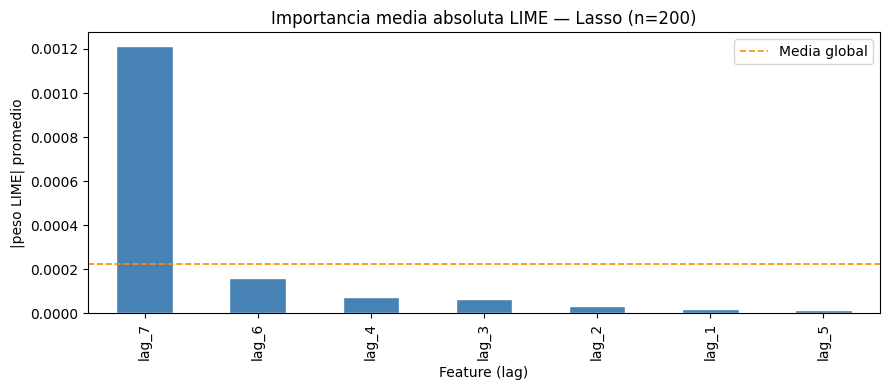

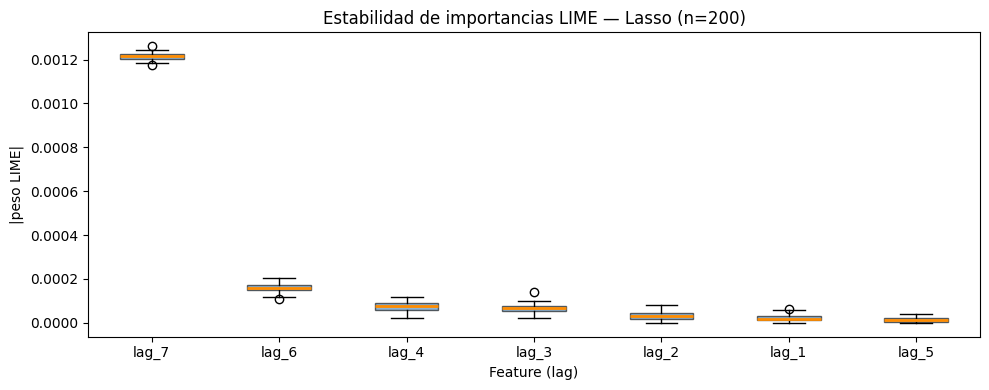

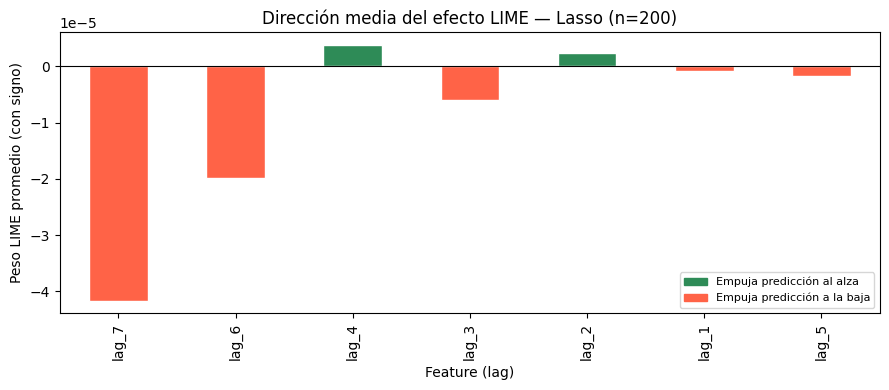

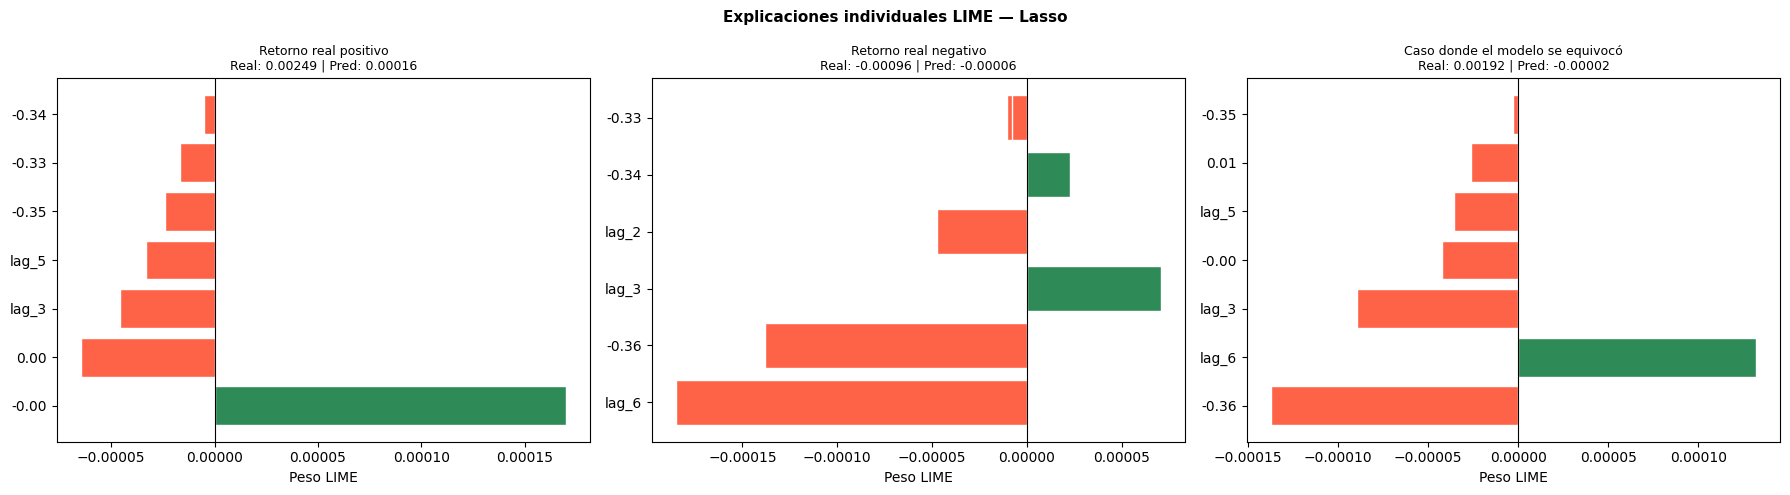


Métricas LIME exportadas → outputs/lime_metricas.csv


In [67]:
from IPython.display import display

# Identificar mejor modelo ML (excluye ARIMA porque no usa features tabulares)
modelos_ml = {k: v for k, v in modelos.items() if k != 'ARIMA'}

mejor_ml = min(
    [(nombre, metodo, res[nombre]['rmse'])
     for nombre in modelos_ml.keys()
     for metodo, res in [('Grid',   resultados_grid),
                         ('Random', resultados_random),
                         ('Optuna', resultados_optuna),
                         ('DEAP',   resultados_deap)]],
    key=lambda x: x[2]
)
nombre_lime     = mejor_ml[0]
ModelClass_lime = modelos_ml[nombre_lime]

if mejor_ml[1] == 'Grid':
    params_lime = resultados_grid[nombre_lime]['params']
elif mejor_ml[1] == 'Random':
    params_lime = resultados_random[nombre_lime]['params']
elif mejor_ml[1] == 'Optuna':
    params_lime = resultados_optuna[nombre_lime]['params']
else:
    params_lime = resultados_deap[nombre_lime]['params']

print(f'Modelo para LIME: {nombre_lime} ({mejor_ml[1]}) — RMSE: {mejor_ml[2]:.5f}')

# Entrenar sobre el último fold
fold_lime   = len(X) - 1
X_train_raw = X[fold_lime].reshape(X[fold_lime].shape[0], -1)
X_test_raw  = Xtest[fold_lime].reshape(Xtest[fold_lime].shape[0], -1)
y_train_raw = y[fold_lime].reshape(y[fold_lime].shape[0], -1)
y_test_raw  = ytest[fold_lime].ravel()

scaler_x_lime = StandardScaler().fit(X_train_raw)
scaler_y_lime = StandardScaler().fit(y_train_raw)

X_train_lime = scaler_x_lime.transform(X_train_raw)
X_test_lime  = scaler_x_lime.transform(X_test_raw)
y_train_lime = scaler_y_lime.transform(y_train_raw).ravel()

try:
    model_lime = ModelClass_lime(**params_lime, random_state=RANDOM_SEED)
except Exception:
    model_lime = ModelClass_lime(**params_lime)

model_lime.fit(X_train_lime, y_train_lime)

feature_names = [f'lag_{i+1}' for i in range(X_train_lime.shape[1])]

def predict_fn(X_scaled):
    return scaler_y_lime.inverse_transform(
        model_lime.predict(X_scaled).reshape(-1, 1)
    ).ravel()

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data = X_train_lime,
    feature_names = feature_names,
    mode          = 'regression',
    random_state  = RANDOM_SEED
)

# ─────────────────────────────────────────────────────────────────────────────
# Importancia media + signo
# ─────────────────────────────────────────────────────────────────────────────
N_LIME = min(200, X_test_lime.shape[0])

importancias_abs = {f: [] for f in feature_names}
importancias_raw = {f: [] for f in feature_names}   # con signo

for i in range(N_LIME):
    exp = explainer.explain_instance(
        X_test_lime[i], predict_fn, num_features=len(feature_names)
    )
    for feat, weight in exp.as_list():
        feat_name = feat.split(' ')[0].split('>')[0].split('<')[0].strip()
        if feat_name in importancias_abs:
            importancias_abs[feat_name].append(abs(weight))
            importancias_raw[feat_name].append(weight)

imp_media = pd.Series(
    {f: np.mean(v) if v else 0.0 for f, v in importancias_abs.items()}
).sort_values(ascending=False)

imp_signed = pd.Series(
    {f: np.mean(v) if v else 0.0 for f, v in importancias_raw.items()}
)

print(f'\nImportancia media absoluta (LIME, n={N_LIME}):')
print(imp_media.to_string())

# ─────────────────────────────────────────────────────────────────────────────
# Figura 1 — Importancia media absoluta (barras)
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
imp_media.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title(f'Importancia media absoluta LIME — {nombre_lime} (n={N_LIME})')
ax.set_xlabel('Feature (lag)')
ax.set_ylabel('|peso LIME| promedio')
ax.axhline(imp_media.mean(), color='darkorange', linestyle='--',
           linewidth=1.2, label='Media global')
ax.legend()
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Figura 2 — Distribución de pesos por lag (boxplot — estabilidad)
# ─────────────────────────────────────────────────────────────────────────────
data_box = [importancias_abs[f] for f in imp_media.index]

fig, ax = plt.subplots(figsize=(10, 4))
bp = ax.boxplot(data_box, patch_artist=True, notch=False,
                medianprops=dict(color='darkorange', linewidth=2))
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.6)
ax.set_xticklabels(imp_media.index, rotation=0)
ax.set_title(f'Estabilidad de importancias LIME — {nombre_lime} (n={N_LIME})')
ax.set_xlabel('Feature (lag)')
ax.set_ylabel('|peso LIME|')
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Figura 3 — Dirección media del efecto por lag (signed weights)
# ─────────────────────────────────────────────────────────────────────────────
imp_signed_sorted = imp_signed[imp_media.index]
colors = ['seagreen' if v >= 0 else 'tomato' for v in imp_signed_sorted]

fig, ax = plt.subplots(figsize=(9, 4))
imp_signed_sorted.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title(f'Dirección media del efecto LIME — {nombre_lime} (n={N_LIME})')
ax.set_xlabel('Feature (lag)')
ax.set_ylabel('Peso LIME promedio (con signo)')
ax.legend(handles=[
    plt.Rectangle((0,0),1,1, color='seagreen', label='Empuja predicción al alza'),
    plt.Rectangle((0,0),1,1, color='tomato',   label='Empuja predicción a la baja')
], fontsize=8)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Figura 4 — Explicaciones individuales: 3 casos concretos
# caso positivo real, caso negativo real, caso donde el modelo se equivocó
# ─────────────────────────────────────────────────────────────────────────────
preds_test = predict_fn(X_test_lime)

# Índices de los 3 casos
idx_pos   = np.where(y_test_raw > 0)[0][0]          # retorno real positivo
idx_neg   = np.where(y_test_raw < 0)[0][0]          # retorno real negativo
# equivocado: signo predicho ≠ signo real
wrong_mask = np.sign(preds_test) != np.sign(y_test_raw)
idx_wrong  = np.where(wrong_mask)[0][0] if wrong_mask.any() else idx_pos

casos = [
    (idx_pos,   'Retorno real positivo'),
    (idx_neg,   'Retorno real negativo'),
    (idx_wrong, 'Caso donde el modelo se equivocó'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (idx, titulo) in zip(axes, casos):
    exp_caso = explainer.explain_instance(
        X_test_lime[idx], predict_fn, num_features=len(feature_names)
    )
    vals  = exp_caso.as_list()
    feats = [v[0].split(' ')[0].split('>')[0].split('<')[0].strip() for v in vals]
    pesos = [v[1] for v in vals]
    colores_caso = ['seagreen' if p >= 0 else 'tomato' for p in pesos]

    ax.barh(feats, pesos, color=colores_caso, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(
        f'{titulo}\nReal: {y_test_raw[idx]:.5f} | Pred: {preds_test[idx]:.5f}',
        fontsize=9
    )
    ax.set_xlabel('Peso LIME')

plt.suptitle(f'Explicaciones individuales LIME — {nombre_lime}',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Exportar métricas LIME como CSV
# ─────────────────────────────────────────────────────────────────────────────
df_lime = pd.DataFrame({
    'feature'           : imp_media.index,
    'importancia_media' : imp_media.values,
    'peso_signed'       : imp_signed[imp_media.index].values,
    'modelo'            : nombre_lime,
    'metodo_optimo'     : mejor_ml[1],
    'n_instancias'      : N_LIME
})
lime_csv_path = 'outputs/lime_metricas.csv'
df_lime.to_csv(lime_csv_path, index=False)

#### Interpretabilidad del modelo Lasso mediante LIME

Para el análisis de interpretabilidad se seleccionó el modelo Lasso optimizado con Optuna, debido a que presentó uno de los menores valores de RMSE entre todos los modelos evaluados, alcanzando un error de 0.00270. Aunque el modelo SVR obtuvo una Direction Accuracy ligeramente superior, Lasso fue elegido porque mantuvo un desempeño muy competitivo y además ofrece una estructura más estable y lineal para interpretar las contribuciones de cada lag mediante LIME.

El análisis de importancia media absoluta mostró que el lag_7 fue, con diferencia, la variable más influyente dentro del modelo, alcanzando un peso promedio de 0.001215. Esto indica que la información contenida siete periodos atrás tuvo la mayor contribución sobre las predicciones de retornos del Bitcoin. En comparación, los demás lags presentaron importancias considerablemente menores, especialmente lag_5 y lag_1, cuyos aportes fueron casi marginales dentro del modelo.

En la gráfica de estabilidad de importancias se observa que lag_7 mantiene una distribución muy consistente entre las distintas observaciones analizadas. La baja dispersión de sus pesos indica que el modelo utiliza esta variable de forma estable y recurrente para generar predicciones. Los demás lags presentan mayor variabilidad y menor magnitud, lo que sugiere que su influencia depende más del contexto específico de cada ventana temporal.

La gráfica de dirección media del efecto permite identificar si cada lag empuja las predicciones hacia retornos positivos o negativos. En este caso, lag_7 presentó un efecto promedio negativo, indicando que incrementos en esta variable suelen asociarse con una reducción en la predicción futura del retorno. Por otro lado, lag_4 y lag_2 mostraron efectos positivos pequeños, contribuyendo ligeramente a incrementar las predicciones del modelo.

Finalmente, las explicaciones individuales obtenidas con LIME evidencian cómo el modelo toma decisiones diferentes dependiendo de cada observación. En el caso de retornos positivos reales, el modelo asignó un peso positivo dominante a uno de los lags principales, mientras que los demás contribuyeron negativamente en menor magnitud. Para los retornos negativos, la mayoría de variables empujaron la predicción hacia valores negativos, especialmente lag_6. En el caso donde el modelo se equivocó, se observó un conflicto entre variables con efectos positivos y negativos, lo que llevó al modelo a predecir un retorno negativo cuando el valor real fue positivo. Esto demuestra que, aunque Lasso logra identificar patrones temporales relevantes, aún existen comportamientos altamente volátiles del mercado que resultan difíciles de modelar correctamente.